# Chapter 40. Time Series & Forecasting

*The runnable half of this chapter.* Every code cell below is the chapter's own code, and the words around it are the chapter's own explanation. Run the cells in order: each one uses names made by the cells before it.

Riverstone Supplies is the single worked example throughout the book, so the data here is the same data you meet in every other chapter.

Built from `manuscript/ch40-time-series-and-forecasting.md`.

# Chapter 40. Time Series & Forecasting

*Part 4 — Machine Learning & Data Science*

> **Chapter at a glance**
>
> **You will learn to:** break a time series into trend, seasonality, cycle, and noise, first by hand · measure autocorrelation, test for stationarity, and know why it matters · build the baselines every forecast must beat, by hand · run exponential smoothing and Holt–Winters, and see the smoothing steps on paper · read ACF and PACF plots and fit a SARIMA model · forecast with a machine learning model on lag features without leaking the future · backtest a forecast the way it will be used, and read the spread of errors · measure accuracy with MAPE, WAPE, and MASE, and know which to quote · turn a forecast into a production plan with safety stock · find anomalies in sensor data, including the kind that point-by-point checks miss.
>
> **Before you start:** Chapter 18, section 18.9 (dates, `resample`, `rolling`, and `shift` in pandas), Chapter 21 (means, standard deviations, z-scores, and the normal distribution), Chapter 22 (confidence intervals, p-values, and correlation, sections 22.1, 22.2, and 22.5), Chapter 35, section 35.8 (likelihood), Chapter 36 (splits and leakage), Chapter 37, section 37.8 (gradient boosting), and Chapter 39, section 39.3 (MAE, MAPE, and WAPE).
>
> **Time needed:** 16–20 hours over three weeks, in four sittings: sections 40.0–40.3 (the data, its parts, autocorrelation, stationarity, baselines); 40.4–40.5 (smoothing and SARIMA); 40.6–40.9 (machine learning, backtesting, metrics, the plan); and 40.10 with the project (sensor anomalies).
>
> **Tools:** Python 3 with pandas, statsmodels, scikit-learn, and Prophet (all free). Prophet is new, and section 40.5 installs it.
>
> **Practice data:** two new Riverstone datasets built by seeded generators. **Demand**: units shipped per product category, weekly (365 weeks) and monthly (84 months), January 2019 to December 2025. **Sensor readings**: one week of one-minute readings from one injection-moulding machine (10,080 rows). Every number in this chapter was calculated, and every output shown is real.

---

## Why this matters

Every business runs on forecasts, most of them made in a spreadsheet by someone who copies last year's number and adds 10%. That method is better than it sounds, and one of the lessons of this chapter is that beating it is harder than most people expect.

- The production planner needs next quarter's demand per category to buy resin and schedule machines. Too low and orders ship late; too high and the warehouse fills with unsold stock.
- Finance needs a revenue forecast with an honest range around it, not a single number that will be wrong.
- The maintenance team wants to know that a machine's heater is failing before the shift supervisor notices scrap.
- An interviewer will ask what makes time series different from other data, and "the rows are in order" is a beginning, not an answer.

Time series break the assumption that most of Part 4 relied on: that rows are independent. Yesterday predicts today. That's what makes forecasting possible, and it's what makes every shortcut from Chapter 36 (random splits, cross-validation, features that peek forward) fail quietly. This chapter is about doing it properly, and about measuring whether the effort beat the spreadsheet.

---

## In plain English

**Think of a shopkeeper who has kept a diary of daily sales for seven years.**

They know the shop is busier every year (**trend**), that October and November are the peak because of the festive season (**seasonality**), that there are good years and bad years that last a while (**cycles**), and that any single day is unpredictable (**noise**). Reading the diary to separate those four is **decomposition**.

Asked what next October will bring, the shopkeeper's first answer is "about what last October brought, plus a bit for growth". That's the **seasonal naive** forecast, and it's surprisingly good. A more careful answer weighs recent months more than old ones (**exponential smoothing**), or notices that a good month tends to follow a good month (**autocorrelation**, the idea behind **ARIMA**).

To know whether a method works, the shopkeeper doesn't check it on last week; they ask, "if I'd used this method at the start of each of the last five years, how wrong would I have been?" That's **backtesting**. And "how wrong" is measured in units short or over across the whole year, not by the worst single day: that's **WAPE**.

Finally, if the shop's fridge thermometer reads 3 degrees higher every hour, the shopkeeper wants to know before the milk goes off, even though no single reading looks alarming. That's **anomaly detection in sensor data**, and the slow kind is the hard kind.

---

## 40.0 Setting up

This chapter's code runs from the folder `companion/ch40/` and reads two datasets that the companion scripts build next to it, in `companion/demand/` and `companion/sensors/`. Open a terminal in the book folder, check that the prompt starts with `(.venv)` (Chapter 17, section 17.0), and run:

**The chapter's output:**

```
# terminal
$ cd companion/ch40
$ python ../generate_riverstone_demand.py
365 weeks x 4 categories; 84 months
$ python ../generate_riverstone_sensors.py
10,080 rows -> machine_readings_week.csv
```

**What each line does:**

- **`cd companion/ch40`** moves into the chapter's folder, so paths such as `../demand/weekly_demand.csv` (one folder up, then into `demand`) find the data.
- **`python ../generate_riverstone_demand.py`** writes `companion/demand/weekly_demand.csv` (one row per product category per week, with columns `week_start`, `category`, and `units`) and `monthly_demand.csv` (columns `month`, `category`, and `units`). The generator is seeded, so it always writes the same numbers.
- **`python ../generate_riverstone_sensors.py`** writes `companion/sensors/machine_readings_week.csv`: one row per minute for machine M01, with `timestamp`, `machine_id`, `temperature_c`, `pressure_bar`, `cycle_seconds`, and `status` (`running` or `stopped`).

pandas, NumPy, and scikit-learn are already in your environment (Chapters 18 and 35), and so is statsmodels (Chapter 22). Start Jupyter from this folder, create a notebook called `ch40.ipynb`, and choose the `.venv` kernel. Every cell in this chapter runs in that notebook, in order.

---

## 40.1 What a time series is made of

### The data

A **time series** is a set of measurements of one thing taken at regular times: units shipped each week, the temperature each minute. Four short cells load it, look for problems, fix them, and pull out the series this chapter works with most. First, read both files:

In [1]:
import numpy as np
import pandas as pd

weekly = pd.read_csv("../demand/weekly_demand.csv", parse_dates=["week_start"])
monthly = pd.read_csv("../demand/monthly_demand.csv", parse_dates=["month"])
print(
    f"weekly:  {weekly.shape}, {weekly['week_start'].min().date()} to"
    f" {weekly['week_start'].max().date()}"
)
print(
    f"monthly: {monthly.shape}, {monthly['month'].min().date()} to"
    f" {monthly['month'].max().date()}"
)

weekly:  (1461, 3), 2019-01-07 to 2025-12-29
monthly: (336, 3), 2019-01-01 to 2025-12-01


- **`parse_dates=["week_start"]`** tells `read_csv` to turn that column into real dates (Chapter 18, section 18.2) instead of leaving it as text, so that `.min()` and `.max()` find the earliest and latest date rather than the first and last in alphabetical order.
- **`.shape`** is (rows, columns). **`.date()`** drops the time of day, which is always midnight here.

The weekly file has 1,461 rows. Four categories over 365 weeks would be 1,460, so something is already off by one. The second cell looks for the two usual problems, a missing value and a duplicated row, and prints the offending rows so you can see them:

In [2]:
print("rows with units missing:")
print(weekly[weekly["units"].isna()])
print("\nrows recorded twice:")
print(weekly[weekly.duplicated(["category", "week_start"], keep=False)])

rows with units missing:
     week_start category  units
1336 2023-08-14  Storage    NaN

rows recorded twice:
     week_start category   units
1256 2022-02-07  Storage  9027.0
1257 2022-02-07  Storage  9027.0


- **`weekly["units"].isna()`** is True where `units` is blank; putting it inside `weekly[...]` keeps only those rows (Chapter 18, section 18.4).
- **`duplicated(["category", "week_start"], keep=False)`** marks rows whose category and week match another row. `keep=False` marks every copy, so you see both; the default, `keep="first"`, would mark only the second.

Two problems were planted to be found: one Storage week with its units missing, and one Storage week recorded twice. Real demand exports have both, and a forecasting model fed a duplicated week will learn a spike that never happened. (A week that is absent altogether, with no row at all, wouldn't show up in either check. For one category's series, `.asfreq("W-MON")` adds a blank row for every missing Monday, and `isna()` then finds it.) The third cell fixes both:

In [3]:
weekly = weekly.drop_duplicates(["category", "week_start"])
weekly["units"] = weekly.groupby("category")["units"].transform(
    lambda u: u.interpolate()
)
print(f"{len(weekly):,} rows, units missing: {weekly['units'].isna().sum()}")
print(
    weekly[
        (weekly["category"] == "Storage")
        & weekly["week_start"].between("2023-08-07", "2023-08-21")
    ]
)

1,460 rows, units missing: 0
     week_start category    units
1335 2023-08-07  Storage  11388.0
1336 2023-08-14  Storage  11083.0
1337 2023-08-21  Storage  10778.0


- **`drop_duplicates(["category", "week_start"])`** removes the second copy of each duplicated week. It keeps the first because `keep="first"` is the default.
- **`groupby("category")["units"].transform(...)`** runs the function on each category's units separately and returns a result the same length as the original column, so it can be written straight back (Chapter 18, section 18.6). Doing it per category matters: without the `groupby`, a Storage gap next to the end of the Kitchen rows could be filled from the wrong product.
- **`lambda u: u.interpolate()`** is a one-line function (Chapter 18, section 18.6): it fills each blank with the value on a straight line between its neighbours. The missing Storage week becomes the midpoint of the weeks either side of it.

The fourth cell takes Kitchen products, Riverstone's largest category, as a monthly series:

In [4]:
kitchen = (
    monthly[monthly["category"] == "Kitchen"]
    .set_index("month")["units"]
    .astype(float)
    .asfreq("MS")
)
print(f"Kitchen, monthly: {len(kitchen)} months, frequency {kitchen.index.freqstr}")
print(kitchen.groupby(kitchen.index.year).sum().astype(int).to_string())

Kitchen, monthly: 84 months, frequency MS
month
2019     656605
2020     611652
2021     728878
2022     814600
2023     932607
2024     962052
2025    1051402


- **`.set_index("month")["units"]`** makes the dates the index and keeps one column: a Series of units labelled by month, the shape every forecasting library expects.
- **`.astype(float)`** stores the units as decimals, because the models' forecasts will be decimals.
- **`.asfreq("MS")`** declares that the series has one value per month, dated at the **m**onth **s**tart (the same code `resample` used in Chapter 18, section 18.9). If a month were missing, `asfreq` would add it as a blank. statsmodels reads this frequency to know what "the next period" means when it forecasts, and warns if it isn't set.
- **`kitchen.groupby(kitchen.index.year).sum()`** adds each year's twelve months: the yearly totals.

### Four components

A time series is usually described as the combination of:

- **Trend:** the long-run direction. Kitchen units grew from 657,000 in 2019 to 1,051,000 in 2025.
- **Seasonality:** a pattern that repeats with a fixed period. Riverstone's peak is October–November, ahead of Diwali, when hotels and retailers stock up.
- **Cycles:** slower swings with no fixed period, such as the economy. Harder to model, often ignored.
- **Noise** (the residual): whatever is left after the others.

**Decomposition** estimates each part. The **multiplicative** version treats seasonality as a *factor* ("October is 1.43 times an average month"), which suits data that grows, because the seasonal swing grows with it. The **additive** version treats it as a fixed *amount* ("October is 30,000 units above an average month"), which suits a series whose swings stay the same size.

### Decomposition by hand

Before any library, do it on a toy: two years of quarterly sales, where the season is four quarters long.

| | Q1 | Q2 | Q3 | Q4 |
|---|--:|--:|--:|--:|
| Year 1 | 100 | 120 | 80 | 100 |
| Year 2 | 110 | 132 | 88 | 110 |

1. **Trend: a centred moving average over one full season.** For Year 1 Q3, average the four quarters around it. Four is even, so the four-quarter window can't be centred on one quarter; the fix is to take the five quarters from Year 1 Q1 to Year 2 Q1 and give the two ends half weight: (½ × 100 + 120 + 80 + 100 + ½ × 110) ÷ 4 = 405 ÷ 4 = **101.25**.
2. **Seasonal ratio = actual ÷ trend.** Year 1 Q3: 80 ÷ 101.25 = **0.790**. The third quarter runs at 79% of the underlying level.
3. **Seasonal index:** average the ratios for each quarter across the years, then scale the four so they average exactly 1. Here each quarter has only one ratio.
4. **Residual = actual ÷ (trend × seasonal index)**: whatever the other two don't explain.

statsmodels does the same:

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

toy = pd.Series(
    [100, 120, 80, 100, 110, 132, 88, 110.0],
    index=pd.date_range("2024-01-01", periods=8, freq="QS"),
)
toy_parts = seasonal_decompose(toy, model="multiplicative", period=4)
print(
    pd.DataFrame(
        {"actual": toy, "trend": toy_parts.trend, "seasonal": toy_parts.seasonal}
    ).round(3)
)

            actual   trend  seasonal
2024-01-01   100.0     NaN     1.033
2024-04-01   120.0     NaN     1.214
2024-07-01    80.0  101.25     0.790
2024-10-01   100.0  104.00     0.962
2025-01-01   110.0  106.50     1.033
2025-04-01   132.0  108.75     1.214
2025-07-01    88.0     NaN     0.790
2025-10-01   110.0     NaN     0.962


- **`pd.date_range("2024-01-01", periods=8, freq="QS")`** makes eight dates, one per **q**uarter **s**tart, to label the values.
- **`seasonal_decompose(toy, model="multiplicative", period=4)`** runs the four steps. `model="multiplicative"` asks for factors (`"additive"` would give amounts), and `period=4` says how many rows one season covers.
- The result has `.trend`, `.seasonal`, and `.resid` Series. The trend for 2024 Q3 is 101.25, as by hand, and the seasonal index for Q3 is 0.790. The first and last two quarters have no trend, because the centred window runs off the ends of the data. With only one ratio per quarter the residual is exactly 1 everywhere; a longer series has several ratios per season, and the residual shows how they differ.

Now the real series. Kitchen's season is twelve months:

In [6]:
parts = seasonal_decompose(kitchen, model="multiplicative", period=12)
seasonal_index = parts.seasonal[:12]
seasonal_index.index = seasonal_index.index.strftime("%b")
print("seasonal index (1.0 = an average month):")
print(seasonal_index.round(3).to_string())

seasonal index (1.0 = an average month):
month
Jan    0.951
Feb    0.886
Mar    0.958
Apr    0.845
May    0.849
Jun    0.820
Jul    0.950
Aug    0.965
Sep    1.022
Oct    1.434
Nov    1.300
Dec    1.021


- **`parts.seasonal[:12]`** keeps the first twelve months: the index repeats every year, so one year says it all.
- **`.strftime("%b")`** turns each date into its short month name (`%b` is the code for "Jan", "Feb", …), so the printout reads by month.

In [7]:
trend = parts.trend.dropna()
deviation = (parts.resid.dropna() - 1).abs()
print(
    f"trend, first and last available: {trend.iloc[0]:,.0f} ->"
    f" {trend.iloc[-1]:,.0f}"
)
print(
    f"residual: typical deviation +/-{parts.resid.dropna().std():.1%}, "
    f"largest {deviation.max():.1%} in {deviation.idxmax():%b %Y}"
)

trend, first and last available: 55,477 -> 86,938
residual: typical deviation +/-10.5%, largest 36.8% in May 2020


- **`.dropna()`** removes the first and last six months, where a centred twelve-month average can't be computed.
- A multiplicative residual is centred on **1.0**, not 0: 1.1 means 10% above what trend and season predict, 0.9 means 10% below. **`(... - 1).abs()`** turns each residual into its distance from 1, so a shortfall counts as much as an excess. **`.idxmax()`** returns the month where that distance is largest.
- **`.std()`** of the residuals is their typical size, printed as a percentage.

![Four stacked panels for Kitchen monthly units: the raw series rising with sharp peaks each autumn, a smooth rising trend line, a repeating seasonal pattern peaking in October, and a residual band with one large dip in spring 2020](figures/fig40-1-decomposition.svg)

*Figure 40.1 — Kitchen demand decomposed into trend, seasonality, and residual. The seasonal factor for October is 1.43; the residual's one large excursion is the spring of 2020.*

**Reading it.** October runs at 143% of an average month and November at 130%, while April–June sit at about 82–85%. The trend rises by about 60% over the period. The residual is typically within about ±10%, with one enormous exception: April to June 2020, when the factory shut in late March and reopened in stages through the summer. May 2020 came in 37% below what trend and season predicted. That event isn't seasonality or trend; it's a one-off that every model in this chapter has to live with.

`seasonal_decompose` returns three parts, not four: there is no cycle component, so any slow cycle is absorbed into the trend line.

> **Watch out: decomposition is a description, not a forecast.** The centred moving average needs data on both sides of each point, so the trend has no value for the first and last six months. It's for understanding the series, not for predicting it.

---

## 40.2 Autocorrelation and stationarity

### Autocorrelation: does last month predict this month?

**Autocorrelation** is the correlation (Chapter 22, section 22.5) between a series and itself shifted back in time. The shift is the **lag**: lag 1 pairs each month with the month before, lag 12 with the same month a year earlier. Take a toy series of six months: 10, 12, 11, 14, 13, 15. Write it beside itself shifted down one row, and each row pairs a month with the one before:

In [8]:
toy_series = pd.Series([10, 12, 11, 14, 13, 15.0])
pairs = pd.DataFrame({"this month": toy_series, "last month": toy_series.shift(1)})
print(pairs)
print(f"autocorrelation at lag 1: {toy_series.autocorr(lag=1):.2f}")

   this month  last month
0        10.0         NaN
1        12.0        10.0
2        11.0        12.0
3        14.0        11.0
4        13.0        14.0
5        15.0        13.0
autocorrelation at lag 1: 0.30


**By hand.** The five complete pairs are (12, 10), (11, 12), (14, 11), (13, 14), and (15, 13). "Last month" has mean 12 and "this month" has mean 13. The deviations from those means are −2, 0, −1, 2, 1 and −1, −2, 1, 0, 2. The products sum to 2 + 0 − 1 + 0 + 2 = 3, and each column's squared deviations sum to 10, so Pearson's r = 3 ÷ √(10 × 10) = **0.30**, the number pandas printed. In a spreadsheet, with the six values in A1:A6, `=CORREL(A2:A6, A1:A5)` gives the same. **`.autocorr(lag=1)`** does exactly this: it correlates the series with `shift(1)` of itself, ignoring the row with no partner.

On Kitchen:

In [9]:
print(f"Kitchen, lag 1:  {kitchen.autocorr(lag=1):.2f}")
print(f"Kitchen, lag 12: {kitchen.autocorr(lag=12):.2f}")

Kitchen, lag 1:  0.78
Kitchen, lag 12: 0.85


A month is strongly correlated with the month before, and even more strongly with the same month last year. That's the memory forecasting methods use, and the reason a random train/test split (Chapter 36) is wrong for a time series: neighbouring rows share information.

### Stationarity

Most classical forecasting methods assume the series is **stationary**: its mean, its variance, and its autocorrelation at each lag stay the same over time. A series with a trend isn't stationary (the mean rises); one with growing seasonal swings isn't either (the variance rises).

The standard fix is **differencing**: model the *change* from one period to the next instead of the level. By hand, the values 100, 110, 125, 130, 150 become the changes 10, 15, 5, 20. pandas does it with `.diff()`:

In [10]:
print(pd.Series([100, 110, 125, 130, 150]).diff().tolist())

[nan, 10.0, 15.0, 5.0, 20.0]


The first value has nothing before it, so it becomes `nan`. **Seasonal differencing** is the same idea at the seasonal lag: this month minus the same month last year, `.diff(12)`, which removes a repeating yearly pattern. Taking logs first (`np.log`) turns growing swings into steady ones, because a log turns "10% bigger" into "the same amount bigger" at any size.

The **augmented Dickey–Fuller (ADF) test** checks the result. Its null hypothesis (Chapter 22, section 22.2) is "not stationary", so a small p-value is evidence that the series is stationary. It fits a small regression of each change on the previous level; the **ADF statistic** is that level's coefficient divided by its standard error, and the more negative it is, the stronger the pull back toward a steady mean. "Augmented" means the regression also includes a few earlier changes, so that ordinary autocorrelation in the changes doesn't fool the test. The statistic is compared with **critical values**: the line it must fall below to count as significant at 5%.

In [11]:
from statsmodels.tsa.stattools import adfuller


def adf_report(name, series):
    result = adfuller(series.dropna(), result_object=True)
    verdict = "stationary" if result.pvalue < 0.05 else "NOT stationary"
    print(
        f"{name:<28} statistic {result.statistic:6.2f}  5% line "
        f"{result.critical_values['5%']:6.2f}  p {result.pvalue:.4f}  {verdict}"
    )


adf_report("units", kitchen)
adf_report("change", kitchen.diff())
adf_report("log units, changed", np.log(kitchen).diff())
adf_report("log, changed, then seasonal", np.log(kitchen).diff().diff(12))

TypeError: adfuller() got an unexpected keyword argument 'result_object'

- **`series.dropna()`**: differencing leaves blanks at the start (one for `diff()`, twelve more for `diff(12)`), and the test can't take blanks.
- **`adfuller(..., result_object=True)`** returns a result with named parts: `.statistic`, `.pvalue`, and `.critical_values`, a dictionary with the 1%, 5%, and 10% lines. (Older code, and many answers online, write `adfuller(series)[:2]` instead, which takes the first two items of a plain tuple, the statistic and the p-value. The named form says what it means.)
- **`result.pvalue < 0.05`** applies the usual 5% line; the statistic falling below the 5% critical value says the same thing.

**Reading it.** The raw units fail (p = 0.98): of course, they trend upward. One difference is enough to pass, and the log-plus-seasonal-difference version, which section 40.5 uses, passes too. The test is a check, not an oracle: it's weak on short series and says nothing about *which* model to fit. Its practical use is to tell you how many times to difference.

---

## 40.3 Baselines that are hard to beat

### Scoring a forecast: WAPE, by hand

Every forecast in this chapter is scored with **WAPE**, which Chapter 39, section 39.3 introduced: the sum of the absolute errors divided by the sum of the actuals, "total units wrong as a share of total units". Three months, by hand:

| Month | Actual | Forecast | Error (actual − forecast) | Absolute error | Error as % of actual |
|---|--:|--:|--:|--:|--:|
| 1 | 100 | 90 | 10 | 10 | 10% |
| 2 | 50 | 60 | −10 | 10 | 20% |
| 3 | 150 | 150 | 0 | 0 | 0% |
| **Total** | **300** | | | **20** | |

**WAPE** = 20 ÷ 300 = **6.7%**. **MAPE**, the average of the last column, is (10% + 20% + 0%) ÷ 3 = **10.0%**: the same 10-unit miss counts double in the small month. That's why a planner prefers WAPE, and section 40.8 compares the two properly. As a function:

In [12]:
def wape(actual, forecast):
    actual = np.asarray(actual)
    forecast = np.asarray(forecast)
    return np.abs(actual - forecast).sum() / actual.sum()


print(f"{wape([100, 50, 150], [90, 60, 150]):.1%}")

6.7%


- **`np.asarray(...)`** turns whatever it's given (a list, a pandas Series, a NumPy array) into a plain array. That matters: subtracting two pandas Series lines them up by their index labels, and a forecast labelled with different dates would produce blanks instead of errors.
- **`np.abs(actual - forecast).sum()`** is the total units wrong, over or under; **`/ actual.sum()`** divides by the total units.

### Three baselines

Chapter 36's rule applies with more force here: never report a forecast without the simple method it must beat. Three baselines, using 2019–2024 to forecast 2025:

- **Naive:** every future month equals the last month seen.
- **Seasonal naive:** each month equals the same month last year.
- **Moving average:** every future month equals the average of the last 12.

**The moving average by hand**, over three months to keep it short: October to December 2024 were 101,587, 101,361, and 72,627 units, so a three-month moving average forecasts (101,587 + 101,361 + 72,627) ÷ 3 = **91,858** for January, and the same 91,858 for every month after it, because it has no newer actuals to average. The twelve-month version works the same way over a whole year.

In [13]:
train = kitchen[:"2024-12"]
test = kitchen["2025"]

naive = np.repeat(train.iloc[-1], 12)
seasonal_naive = train["2024"].to_numpy()
moving_average = np.repeat(train.iloc[-12:].mean(), 12)
print(
    f"last value (Dec 2024): {train.iloc[-1]:,.0f}   mean of 2024:"
    f" {train.iloc[-12:].mean():,.0f}"
)
print(
    f"January 2025 actual {test.iloc[0]:,.0f}: naive {naive[0]:,.0f}, seasonal"
    f" naive {seasonal_naive[0]:,.0f}, moving average {moving_average[0]:,.0f}"
)

last value (Dec 2024): 72,627   mean of 2024: 80,171
January 2025 actual 75,641: naive 72,627, seasonal naive 71,958, moving average 80,171


- **`kitchen[:"2024-12"]`** keeps every month up to December 2024, and **`kitchen["2025"]`** the twelve months of 2025. With a date index, pandas reads a partial date string as "everything in that period" (Chapter 18, section 18.9).
- **`np.repeat(value, 12)`** makes an array of twelve copies of one value: the naive and moving-average forecasts are the same number every month.
- **`train["2024"].to_numpy()`** is 2024's twelve values, used as the forecast for 2025's twelve months in order.
- **`train.iloc[-12:]`** is the last twelve rows by position (Chapter 18, section 18.4).

In [14]:
forecasts = {
    "naive": naive,
    "seasonal naive": seasonal_naive,
    "12-month moving average": moving_average,
}
for name, forecast in forecasts.items():
    print(f"{name:<26} WAPE over 2025 {wape(test, forecast):.1%}")

naive                      WAPE over 2025 17.7%
seasonal naive             WAPE over 2025 10.0%
12-month moving average    WAPE over 2025 14.1%


The dictionary `forecasts` collects every method's 2025 forecast under its name; later sections add to it.

**Reading it.** The seasonal naive forecast, which needs no library and no skill, is within 10% over the year. Plain naive (17.7%) and the moving average (14.1%) do worse because they ignore the seasonal pattern entirely: the moving average predicts 80,171 for a January that runs well below average. **Seasonal naive is the number to beat** for any strongly seasonal series, and several methods below don't beat it.

---

## 40.4 Exponential smoothing

### Simple smoothing, by hand

**Simple exponential smoothing** keeps a running level that moves part of the way toward each new observation:

> new level = α × latest actual + (1 − α) × old level

where **α** (alpha), between 0 and 1, sets how fast the level reacts. It's a weighted average of the whole history with weights that decay exponentially into the past: last month gets α, the month before α(1 − α), and so on. Five months of Kitchen data with α = 0.3:

In [15]:
values = train["2024-08":"2024-12"]
alpha = 0.3
level = values.iloc[0]
print(f"start: level = first value = {level:,.0f}")
for month, y in values.iloc[1:].items():
    level = alpha * y + (1 - alpha) * level
    print(
        f"{month:%b %Y}: actual {y:>8,.0f}   level = 0.3 "
        f"x {y:,.0f} + 0.7 x previous = {level:>9,.0f}"
    )

start: level = first value = 81,128
Sep 2024: actual   86,644   level = 0.3 x 86,644 + 0.7 x previous =    82,783
Oct 2024: actual  101,587   level = 0.3 x 101,587 + 0.7 x previous =    88,424
Nov 2024: actual  101,361   level = 0.3 x 101,361 + 0.7 x previous =    92,305
Dec 2024: actual   72,627   level = 0.3 x 72,627 + 0.7 x previous =    86,402


**Reading it.** The level lags the actuals: it rises toward the October–November peak but never reaches it, and it comes down slowly in December. That's the point of smoothing (it ignores noise) and its weakness (it ignores real seasonal jumps too). Simple smoothing forecasts a flat line at the last level, so it can't follow seasonality.

### Holt's trend and Holt–Winters, by hand

**Holt's method** keeps a second running quantity, the **trend** (the change per month), smoothed with its own parameter, **β** (beta). **Holt–Winters** adds a third, a **seasonal factor** for each month of the year, smoothed with **γ** (gamma). Each new month updates all three, in words:

1. **Level:** α × (the new actual, with its seasonal factor divided out) + (1 − α) × (old level + old trend).
2. **Trend:** β × (new level − old level) + (1 − β) × old trend.
3. **Seasonal factor** for this month of the year: γ × (new actual ÷ new level) + (1 − γ) × its old value.

One Holt step, with no season: level 100, trend 5, a new actual of 112, α = 0.5, and β = 0.2.

In [16]:
level, trend_now, actual = 100, 5, 112
new_level = 0.5 * actual + 0.5 * (level + trend_now)
new_trend = 0.2 * (new_level - level) + 0.8 * trend_now
print(
    f"level {new_level}, trend {new_trend:.1f}, forecast for next month"
    f" {new_level + new_trend:.1f}"
)

level 108.5, trend 5.7, forecast for next month 114.2


The old level and trend predicted 105; the actual came in at 112, so the level moves halfway (α = 0.5) toward it, to 108.5. The level rose by 8.5 against an expected 5, so the trend moves a fifth of the way (β = 0.2) from 5 toward 8.5, to 5.7. The seasonal update works the same way on each month's factor. If **γ = 0**, the third update keeps the old factor every time: **the seasonal factors are frozen** at whatever the first years suggested.

### Holt–Winters in statsmodels

statsmodels chooses α, β, and γ by minimizing the in-sample error, the one-step-ahead misses over the training years. First simple smoothing, then the full model:

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ses = ExponentialSmoothing(train).fit()
print(
    f"simple smoothing: alpha {ses.params['smoothing_level']:.3f}   "
    f"WAPE 2025 {wape(test, ses.forecast(12)):.1%}"
)

simple smoothing: alpha 0.993   WAPE 2025 17.5%


- **`ExponentialSmoothing(train)`** with no other settings is simple smoothing: a level only.
- **`.fit()`** chooses α. **`.params`** is a dictionary of the fitted values; `"smoothing_level"` is α.
- **`.forecast(12)`** gives the next twelve months.

In [18]:
holt_winters = ExponentialSmoothing(
    train, trend="add", seasonal="mul", seasonal_periods=12
).fit()
hw_fc = holt_winters.forecast(12)
forecasts["Holt-Winters"] = hw_fc.to_numpy()
print(
    f"Holt-Winters: alpha {holt_winters.params['smoothing_level']:.3f}  "
    f"beta {holt_winters.params['smoothing_trend']:.3f}  "
    f"gamma {holt_winters.params['smoothing_seasonal']:.3f}   "
    f"WAPE 2025 {wape(test, hw_fc):.1%}"
)
print(
    pd.DataFrame({"actual": test[:4], "forecast": hw_fc[:4].round()})
    .astype(int)
    .to_string()
)

Holt-Winters: alpha 0.725  beta 0.011  gamma 0.000   WAPE 2025 17.5%
            actual  forecast
2025-01-01   75641     67183
2025-02-01   69282     64400
2025-03-01   80091     68328
2025-04-01   77281     62052


- **`trend="add"`**: the trend is an amount, units per month, added each month.
- **`seasonal="mul"`**: the seasonal effect is a factor that multiplies, like the decomposition's index in section 40.1. `"add"` would make it a fixed number of units.
- **`seasonal_periods=12`**: one season is twelve rows.
- **`params`** keys: `"smoothing_level"` is α, `"smoothing_trend"` is β, and `"smoothing_seasonal"` is γ.
- The last line puts the first four months of 2025 side by side.

**Reading it, plainly.** Holt–Winters scores **17.5%**, worse than seasonal naive's 10%. Look at why: the fitted α is 0.725, so the level chases the latest month, and γ is 0.000, so the seasonal factors were fixed from the early years and never updated. Starting from a low December 2024, the forecast for early 2025 runs 7–20% below actual. The optimizer minimized *in-sample* error and found a combination that fits the past and forecasts badly. This is a common outcome on short, noisy series; the fix is usually to constrain the parameters (`use_boxcox`, `damped_trend`, or fixing γ) and to judge by backtest, not by in-sample fit.

> **When smoothing works well:** stable series with clear seasonality and lots of history, and as a fast, explainable default in planning tools (most commercial demand-planning software runs some form of Holt–Winters). It's also the method a planner can maintain in a spreadsheet.

---

## 40.5 ARIMA and SARIMA

### The idea

**ARIMA** models a stationary series as a combination of:

- **AR** (autoregressive, order *p*): this month depends on the last *p* months' values.
- **I** (integrated, order *d*): the series was differenced *d* times to make it stationary.
- **MA** (moving average, order *q*): this month depends on the last *q* months' *forecast errors*.

> **Watch out: two different "moving averages".** The MA in ARIMA is not a moving average of values like section 40.3's baseline. It means "uses past forecast errors". The name is historical, and the two are unrelated.

**SARIMA** adds the same three at the seasonal lag (12 months here), written (*p*, *d*, *q*)(*P*, *D*, *Q*)<sub>*s*</sub>, with *s* the season length. The classic seasonal model is the **airline model**, (0, 1, 1)(0, 1, 1)<sub>12</sub>, named after the airline-passenger series it was first fitted to: difference once and seasonally once, then explain what's left with one error term and one seasonal error term. This section fits (1, 1, 1)(0, 1, 1)<sub>12</sub>, which adds one autoregressive term and scores better on AIC (defined below); exercise 7 compares it with the airline model and simpler cousins.

### Reading ACF and PACF

The **autocorrelation function (ACF)** is section 40.2's autocorrelation computed at every lag, 1, 2, 3, and so on. The **partial autocorrelation function (PACF)** asks a narrower question: how much does the value two months ago still tell you *after* last month has been taken into account? If each month simply copies part of the month before, the lag-2 autocorrelation will be positive, because month 2 ago shaped last month, which shaped this month; but the partial autocorrelation at lag 2 will be near zero, because once you know last month, two months ago adds nothing.

On a properly differenced series, isolated spikes in the ACF suggest MA terms and spikes in the PACF suggest AR terms. A spike counts if it's outside a band of about **±2 ÷ √n**, where *n* is the number of values: an approximate 95% band (Chapter 22, section 22.1) for a correlation whose true value is zero.

In [19]:
from statsmodels.tsa.stattools import acf, pacf

stationary = np.log(train).diff().diff(12).dropna()
acf_values = acf(stationary, nlags=24)
pacf_values = pacf(stationary, nlags=24)
band = 2 / np.sqrt(len(stationary))
print(f"{len(stationary)} values, band +/-{band:.2f}")
print("lag   ACF    PACF")
for lag in range(1, 25):
    if (
        abs(acf_values[lag]) > band
        or abs(pacf_values[lag]) > band
        or lag in (1, 2, 12)
    ):
        print(f"{lag:>3}  {acf_values[lag]:5.2f}  {pacf_values[lag]:5.2f}")

59 values, band +/-0.26
lag   ACF    PACF
  1   0.06   0.06
  2  -0.07  -0.07
  9   0.30   0.33
 12  -0.34  -0.48
 22   0.10   0.27


- **`np.log(train).diff().diff(12).dropna()`** is section 40.2's stationary version: logs, one ordinary difference, one seasonal difference. Of the 72 training months, the two differences use up 13, which leaves 59.
- **`acf(stationary, nlags=24)`** returns 25 numbers, the autocorrelations at lags 0 to 24. Lag 0 is always 1 (a series is perfectly correlated with itself), which is why the loop starts at 1. `pacf` is the same for the partial version. statsmodels' `acf` uses one mean for the whole series rather than a separate mean for each column of pairs, so on a very short series it differs a little from pandas' `autocorr`; on section 40.2's six-value toy it gives 0.10 rather than 0.30.
- The loop prints lags 1, 2, and 12, plus any lag outside the band.

To see all 24 lags, statsmodels draws the plots directly:

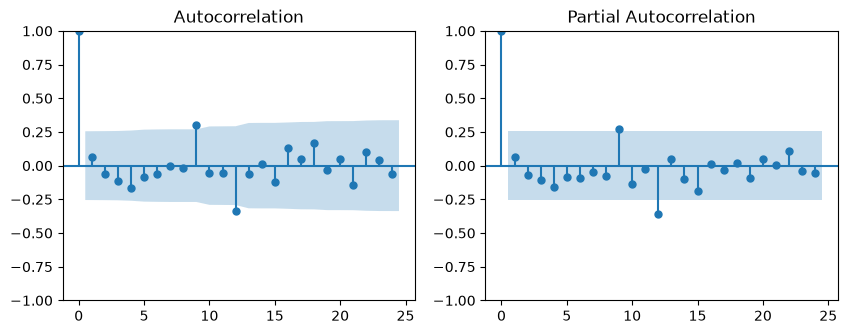

In [20]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
plot_acf(stationary, lags=24, ax=axes[0])
plot_pacf(stationary, lags=24, ax=axes[1])
plt.show()

`plt.subplots(1, 2, figsize=(10, 3.5))` makes one row of two panels, 10 by 3.5 inches (Chapter 18, section 18.11). `plot_acf` and `plot_pacf` draw one bar per lag up to `lags=24` and shade the significance band; `ax=` puts each in its own panel. Figure 40.2 is the same picture, redrawn for print.

![Two bar charts of the differenced log Kitchen series: the ACF with a large negative bar at lag 12 and a smaller positive one at lag 9, and the PACF with a large negative bar at lag 12 and smaller ones at lags 9 and 22 crossing the dashed significance lines at plus and minus 0.26](figures/fig40-2-acf-pacf.svg)

*Figure 40.2 — ACF and PACF of the differenced log series. Bars outside the dashed ±0.26 band are marked. A few isolated lags cross it (9, and 22 in the PACF); lag 12 is the one that matters, the sign of a seasonal moving-average term.*

**Reading it.** After differencing, the clear signal is a negative spike at lag 12 in both plots (−0.34 and −0.48, well outside the ±0.26 band). A negative ACF spike at the seasonal lag after seasonal differencing is the textbook sign of a seasonal MA(1) term, which is the *Q* = 1 in the model. Lags 9 and 22 also poke outside the band, but a 95% band will be crossed by about one lag in twenty by chance alone, and neither has a business reason, so they're treated as noise. The short lags (1 and 2) are well within the band, which points to the airline model, or even to no ordinary AR or MA terms at all. In practice most people try the standard model, check the residuals, and then let `auto_arima` (from the `pmdarima` package) or a small grid search over orders, judged by AIC and by backtest, choose among a few candidates. That's how the extra AR term here was chosen.

### Fitting SARIMA

In [21]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(np.log(train), order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(
    disp=False
)
print(sarima.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6965      0.175      3.973      0.000       0.353       1.040
ma.L1         -0.9966      3.580     -0.278      0.781      -8.013       6.020
ma.S.L12      -0.6321      0.235     -2.687      0.007      -1.093      -0.171
sigma2         0.0163      0.057      0.288      0.773      -0.094       0.127


**How it works:**

- **`np.log(train)`**: the model is fitted to log units, so the seasonal swing is proportional and the forecast can't go negative. `np.exp` converts forecasts back to units.
- **`order=(1, 1, 1)`** is (*p*, *d*, *q*); **`seasonal_order=(0, 1, 1, 12)`** is (*P*, *D*, *Q*, *s*): four numbers, with the season length last.
- **`.fit(disp=False)`** finds the coefficients by maximum likelihood (Chapter 35, section 35.8); `disp=False` stops it printing the optimizer's progress.
- **`summary().tables[1]`** is the coefficient table from the model's full report. The row names say which term each is: `ar.L1` is the AR term at lag 1, `ma.L1` the MA term at lag 1, `ma.S.L12` the seasonal MA term at lag 12, and `sigma2` the variance of the model's one-step errors, on the log scale.
- The columns read like Chapter 30's regression table (section 30.11): `coef` is the estimate, `std err` its standard error, `z` the estimate divided by its standard error, `P>|z|` the p-value for "this coefficient is really zero" (Chapter 22, section 22.2), and `[0.025 0.975]` the 95% confidence interval.

> **AIC, the Akaike information criterion.** A score for how well a model fits, with a penalty for every parameter it uses: AIC = 2 × (number of parameters) − 2 × (log-likelihood), where the log-likelihood (Chapter 35, section 35.8) measures how probable the data is under the fitted model. Lower is better. Adding a parameter always improves the fit a little, so it has to improve the log-likelihood by more than 1 to lower the AIC. Only compare AICs of models fitted to exactly the same data: the same series, the same transformation, and the same differencing.

In [22]:
sarima_fc = np.exp(sarima.forecast(12))
forecasts["SARIMA"] = sarima_fc.to_numpy()
print(
    f"SARIMA (1,1,1)(0,1,1)12 on log units: WAPE 2025 {wape(test, sarima_fc):.1%}  "
    f" AIC {sarima.aic:.1f}"
)

SARIMA (1,1,1)(0,1,1)12 on log units: WAPE 2025 4.0%   AIC -58.0


`sarima.aic` is the fitted model's AIC; on its own it means little, and it becomes useful when exercise 7 compares it with other orders.

In [23]:
interval = np.exp(sarima.get_forecast(12).conf_int(alpha=0.2))
print(
    f"December 2025: forecast {sarima_fc.iloc[-1]:,.0f}, 80% interval"
    f" {interval.iloc[-1, 0]:,.0f} to {interval.iloc[-1, 1]:,.0f}, actual"
    f" {test.iloc[-1]:,.0f}"
)

December 2025: forecast 90,617, 80% interval 70,877 to 115,855, actual 88,926


**`get_forecast(12)`** returns the forecast together with its uncertainty, and **`.conf_int(alpha=0.2)`** gives an 80% prediction interval (alpha is the share left outside, 20%), one row per month with a lower and an upper column. `np.exp` turns the log-scale interval back into units.

**Reading it.** SARIMA scores **4.0%** on 2025, far better than seasonal naive. The coefficients say what the plots said: a seasonal MA term of −0.64 (significant) and an AR(1) of 0.70. The MA(1) coefficient of −0.997 has a huge standard error, and that is a diagnosis in itself. An MA coefficient of about −1 after an ordinary difference is the classic sign of **over-differencing**: one difference too many was taken, and the model is using the MA term to cancel it. The AR(1) and MA(1) terms work as a pair to undo the *d* = 1. The usual alternative is *d* = 0 with a constant, which exercise 7 fits, alongside simpler orders; the answer to "can this model be simplified by dropping a term?" is no.

The December forecast of 90,680 came with an 80% interval of 71,000 to 116,000; the actual, 88,926, landed inside it. **Always show the interval.** A point forecast without one invites the reader to believe it.

### Forecasting libraries

Beyond statsmodels, three tools are worth knowing:

- **Prophet** (Meta): fits trend, seasonality, and holiday effects as additive curves, handles missing data and outliers gracefully, and needs almost no tuning. Popular with analysts for exactly that reason.
- **pmdarima**: `auto_arima`, which searches SARIMA orders automatically.
- **statsforecast** and **sktime**: fast, scikit-learn-style libraries for forecasting many series at once, which is what a demand planner with 500 products needs.

Prophet is new to your environment. In the terminal, with `(.venv)` showing:

**The chapter's output:**

```
# terminal
$ python -m pip install prophet
```

The install ends with a line starting `Successfully installed`. Prophet does its fitting with a separate engine called CmdStan, which comes with the package; the first fit can take a little longer while it starts up. Add it to your `requirements.txt` with `python -m pip freeze > requirements.txt`, as in Chapter 17.

In [ ]:
import logging

from prophet import Prophet

logging.getLogger("cmdstanpy").setLevel(logging.ERROR)


def prophet_forecast(history, n):
    model = Prophet(
        yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False
    )
    model.fit(pd.DataFrame({"ds": history.index, "y": history.to_numpy()}))
    future = model.make_future_dataframe(
        periods=n, freq="MS", include_history=False
    )
    return model.predict(future)["yhat"].to_numpy()


forecasts["Prophet"] = prophet_forecast(train, 12)
print(f"Prophet: WAPE 2025 {wape(test, forecasts['Prophet']):.1%}")

> **Not run here.** This cell needs something this machine does not have: a database, an API key, a running service, or command-line arguments. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
Prophet: WAPE 2025 5.9%
```

**How it works:**

- **`logging.getLogger("cmdstanpy").setLevel(logging.ERROR)`**: CmdStan reports every fit through Python's `logging` module (Chapter 18, section 18.15); this line keeps only its error messages, so the notebook isn't filled with progress lines.
- **Prophet demands two columns named exactly `ds` (the date) and `y` (the value)**, which is what the `DataFrame` builds from the series' index and values.
- **`yearly_seasonality=True`** fits the within-year pattern. **`weekly_seasonality=False`** and **`daily_seasonality=False`** switch off the other two patterns Prophet looks for by default, because the data is monthly: there is no day-of-week or hour-of-day pattern to find.
- **`make_future_dataframe(periods=n, freq="MS", include_history=False)`** builds a `ds` column of the next `n` month-starts after the training data.
- **`predict`** returns many columns. **`yhat`** is the forecast, and `yhat_lower` and `yhat_upper` are Prophet's 80% interval. The function returns only `yhat`, as an array, so that it can be scored like the others, and section 40.9 and exercise 9 reuse it.

**Reading it.** Prophet scores **5.9%** on 2025 without any settings beyond "there's yearly seasonality". Not as good as the hand-chosen SARIMA here, and much better than Holt–Winters or seasonal naive, for one line of configuration. For someone forecasting dozens of series with no time to tune each, that trade is often the right one.

---

## 40.6 Machine learning for forecasting

Gradient boosting (Chapter 37, section 37.8) can forecast too, if the time series is turned into a table: each row is one period, and its features are **lags** (the values 1, 2, …, 52 periods earlier), **rolling statistics** of past values, and **calendar** features (week of year). The target is this period's value. With 84 months that's too few rows; the weekly series (365 rows) is where this approach starts to make sense.

### Step 1: build the features

In [25]:
wk = (
    weekly[weekly["category"] == "Kitchen"]
    .set_index("week_start")["units"]
    .astype(float)
)
LAGS = [1, 2, 3, 4, 8, 13, 26, 52]
features = pd.DataFrame({"units": wk})
for lag in LAGS:
    features[f"lag_{lag}"] = wk.shift(lag)
features["mean_4"] = wk.shift(1).rolling(4).mean()
features["mean_13"] = wk.shift(1).rolling(13).mean()
features["week_of_year"] = features.index.isocalendar().week.to_numpy().astype(int)
features["year"] = features.index.year
print(
    features[["units", "lag_1", "lag_52", "mean_4", "week_of_year"]]
    .head(3)
    .round(0)
)
print(f"{len(features)} weeks; complete rows: {len(features.dropna())}")
features = features.dropna()

              units    lag_1  lag_52  mean_4  week_of_year
week_start                                                
2019-01-07  11000.0      NaN     NaN     NaN             2
2019-01-14  11876.0  11000.0     NaN     NaN             3
2019-01-21  10722.0  11876.0     NaN     NaN             4
365 weeks; complete rows: 313


**How it works:**

- **`wk.shift(lag)`** moves the series down `lag` rows (Chapter 18, section 18.9), so each week's `lag_1` is the week before's units: in the printout, week two's `lag_1` is week one's `units`. The loop makes one column per lag.
- **`wk.shift(1).rolling(4).mean()`**: the average of the four weeks *before* this one. The shift comes first, so the average never includes the week being predicted. That's the time-series version of Chapter 36's prediction-moment rule, and getting it wrong (using `rolling(4)` on the unshifted series) is the most common leak in ML forecasting.
- **`features.index.isocalendar().week`** is the week number of the year, 1 to 53 (the "ISO" calendar, where weeks start on Monday). `.to_numpy().astype(int)` stores it as plain whole numbers.
- **`features.index.year`** is the calendar year.
- The first rows have blanks (`NaN`): week one has no week before it, and `lag_52` needs a full year of history. **`dropna()`** removes every row with a blank, which is the first 52 weeks: 365 − 52 = 313 complete rows.

### Step 2: split by time and fit

In [26]:
from sklearn.ensemble import HistGradientBoostingRegressor

wk_train, wk_test = features.loc[:"2024-12-31"], features.loc["2025"]
X_cols = [c for c in features.columns if c != "units"]
gbr = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05, max_depth=4, random_state=40
)
gbr.fit(wk_train[X_cols], wk_train["units"])
print(
    f"{len(wk_train)} training weeks, {len(wk_test)} test weeks, {len(X_cols)}"
    " features"
)

261 training weeks, 52 test weeks, 12 features


- **`features.loc[:"2024-12-31"]`** is every week up to the end of 2024, and **`.loc["2025"]`** the weeks of 2025: the split is by time, never at random.
- **`X_cols`** lists every column except the target, `units`: the eight lags, two rolling means, week of year, and year.
- **`HistGradientBoostingRegressor`** is the regression version of the boosting classifier from Chapter 37, section 37.8, which explained `max_iter` (the number of trees), `learning_rate`, and `max_depth`. `random_state=40` fixes its random choices so the result repeats.
- **A note on `year`:** trees can't extrapolate. Every 2025 row has a `year` beyond anything in training, so the model treats 2025 exactly like 2024; the lags carry the growth.

### Step 3: score it against the weekly baseline

In [27]:
print(
    "one-week-ahead WAPE on 2025 weeks:"
    f" {wape(wk_test['units'], gbr.predict(wk_test[X_cols])):.1%}"
)
wk_seasonal_naive = wk.shift(52).reindex(wk_test.index)
print(
    "weekly seasonal naive (same week last year):"
    f" {wape(wk_test['units'], wk_seasonal_naive):.1%}"
)

one-week-ahead WAPE on 2025 weeks: 9.4%
weekly seasonal naive (same week last year): 11.3%


- **`wk.shift(52)`** is each week's value from 52 weeks earlier: the weekly seasonal naive forecast. **`.reindex(wk_test.index)`** keeps just the 2025 weeks, in the same order as the test rows.

**Reading it.** One week ahead, the model's WAPE is 9.4% against 11.3% for the weekly seasonal naive. But "one week ahead" means each prediction used the *actual* previous weeks, which a planner forecasting a year out won't have. The fair test is **recursive**: forecast week 1, feed the forecast in as the lag for week 2, and so on:

In [28]:
history = wk[:"2024-12-31"].copy()
recursive = []
for week in wk_test.index:
    row = {f"lag_{lag}": history.iloc[-lag] for lag in LAGS}
    row["mean_4"] = history.iloc[-4:].mean()
    row["mean_13"] = history.iloc[-13:].mean()
    row["week_of_year"] = int(week.isocalendar().week)
    row["year"] = week.year
    prediction = gbr.predict(pd.DataFrame([row])[X_cols])[0]
    recursive.append(prediction)
    history.loc[week] = prediction  # feed the forecast back in, never the actual
recursive = pd.Series(recursive, index=wk_test.index)
print(
    "52-week recursive forecast, WAPE on 2025:"
    f" {wape(wk_test['units'], recursive):.1%}"
)

52-week recursive forecast, WAPE on 2025: 9.3%


**How it works:**

- **`history`** starts as the actual weeks up to December 2024. `.copy()` makes it a separate Series, so adding to it doesn't change `wk`.
- For each 2025 week, **`row`** builds the same twelve features the model was trained on, but from `history`: `history.iloc[-lag]` is the value `lag` weeks back, and `history.iloc[-4:].mean()` the last four weeks' average.
- **`pd.DataFrame([row])[X_cols]`** turns the dictionary into a one-row table with the columns in training order; **`[0]`** takes the single prediction out of the array `predict` returns.
- **`history.loc[week] = prediction`** appends the *forecast* as if it were that week's value, so the next week's lags are built from forecasts, exactly as they would be a year ahead.

**Reading it.** Recursively, the weekly model scores 9.3% over 2025, still ahead of the weekly baseline. Surprisingly, that's no worse than the one-week-ahead score. The model's own forecasts are smoother than the noisy actuals, and on this calm year feeding them back cost nothing. Don't expect that in general: 52 weeks is a single sample, and exercise 12 shows errors growing with the horizon.

The planner, though, plans in months. Sum the weekly forecast into months and compare with the monthly series:

In [29]:
monthly_from_weekly = recursive.resample("MS").sum()
print(
    "weekly forecast summed to months:"
    f" {wape(test, monthly_from_weekly.reindex(test.index)):.1%}"
)
actual_by_monday = wk["2025"].resample("MS").sum()
print(
    "actual weekly units summed the same way:"
    f" {wape(test, actual_by_monday.reindex(test.index)):.1%}"
)

weekly forecast summed to months: 14.3%
actual weekly units summed the same way: 9.5%


- **`resample("MS").sum()`** adds up the weeks whose `week_start` falls in each month (Chapter 18, section 18.9).
- The second line does the same to the *actual* weekly units, with no forecasting at all.

**Reading it.** Summed into months, the forecast scores 14.3% against the monthly series, far worse than SARIMA's 4.0%. But look at the second line: even the true weekly units, summed the same way, are 9.5% away from the monthly series. **Weekly totals don't add up to calendar months.** A week that starts on Monday 29 September is counted entirely in September, although four of its days are in October, and the last week of 2025 includes four days of 2026. Most of the gap is that bookkeeping mismatch, not forecasting error; spreading each week's units over its seven days before summing by month would remove most of it.

That's the honest position of ML forecasting on a single clean series: competitive, not dominant. Where it wins is with **many series and external features**: promotions, prices, weather, holidays, and the demand of related products, which SARIMA can't easily use.

> **Watch out: the calendar can leak too.** A feature such as "total units this year" or "average price this quarter" includes the future if computed over the whole period. Every feature must be computable on the forecast date from data available then.

---

## 40.7 Backtesting

One test year is one sample. 2025 happened to be an ordinary year; a method that does well on it might have failed in 2021. **Backtesting** (rolling-origin evaluation) repeats the forecast from several past starting points, the **origins**, and looks at all the scores. Each repeat is a **fold**. With 84 months, a 12-month horizon, and five folds, fold 1 cuts the history at month 24 and forecasts months 25–36 (2021); each later fold moves the cut forward a year:

In [30]:
for fold in range(5):
    cut = 84 - 12 * (5 - fold)
    print(
        f"fold {fold + 1}: train on months 1-{cut} ({cut} months), forecast"
        f" {kitchen.index[cut]:%Y}"
    )

fold 1: train on months 1-24 (24 months), forecast 2021
fold 2: train on months 1-36 (36 months), forecast 2022
fold 3: train on months 1-48 (48 months), forecast 2023
fold 4: train on months 1-60 (60 months), forecast 2024
fold 5: train on months 1-72 (72 months), forecast 2025


The cut is 84 − 12 × (folds left): 24, 36, 48, 60, then 72 months. Fold 1 has only two years of history, one of them the 2020 shutdown, which partly explains why every method does worst there. Figure 40.3 draws the five folds.

In [31]:
def backtest(series, make_forecast, horizon=12, folds=5):
    scores = []
    for fold in range(folds):
        cut = len(series) - horizon * (folds - fold)
        history, future = series.iloc[:cut], series.iloc[cut : cut + horizon]
        scores.append(wape(future, make_forecast(history, horizon)))
    return np.array(scores)

- **`series.iloc[:cut]`** is the history the method may see; **`series.iloc[cut : cut + horizon]`** the twelve months it's scored on.
- **`make_forecast`** is any function that takes a history and a number of months and returns that many forecasts. Passing a function into a function is how one `backtest` serves every method.

Each method becomes such a function. `lambda h, n: ...` (Chapter 18, section 18.6) is a tiny function that takes the history `h` and the horizon `n`:

In [32]:
methods = {
    "seasonal naive": lambda h, n: h.iloc[-12:].to_numpy()[:n],
    "Holt-Winters": (
        lambda h, n: ExponentialSmoothing(
            h, trend="add", seasonal="mul", seasonal_periods=12
        )
        .fit()
        .forecast(n)
        .to_numpy()
    ),
    "SARIMA": (
        lambda h, n: np.exp(
            SARIMAX(np.log(h), order=(1, 1, 1), seasonal_order=(0, 1, 1, 12))
            .fit(disp=False)
            .forecast(n)
        ).to_numpy()
    ),
}

- The three functions are the models from sections 40.3–40.5, refitted on whatever history they're given. `h.iloc[-12:].to_numpy()[:n]` is the last twelve months, cut to `n` values; the other two fit a fresh model and call `.forecast(n)`.
- Holt–Winters and SARIMA need at least two full years to estimate their seasonal parts, which fold 1 just has.

Now run every method through every fold:

In [33]:
print(
    f"{'method':<16} "
    + "  ".join(f"fold {i + 1}" for i in range(5))
    + "    mean    worst"
)
for name, fn in methods.items():
    s = backtest(kitchen, fn)
    print(
        f"{name:<16} "
        + "  ".join(f"{v:6.1%}" for v in s)
        + f"  {s.mean():6.1%}  {s.max():6.1%}"
    )

method           fold 1  fold 2  fold 3  fold 4  fold 5    mean    worst
seasonal naive    20.7%   10.5%   12.7%   10.2%   10.0%   12.8%   20.7%


Holt-Winters      14.4%   11.9%   14.0%    8.2%   17.5%   13.2%   17.5%


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


SARIMA            16.3%   15.0%   10.8%    9.9%    4.0%   11.2%   16.3%


- **`backtest(kitchen, fn)`** returns the five fold scores for one method; `s.mean()` and `s.max()` are its average and worst fold.
- **`"  ".join(...)`** glues the five formatted scores into one line with two spaces between them.

When you run this cell, statsmodels also prints a few warnings (in a pink box in Jupyter): `EstimationWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.`, and `Non-invertible starting seasonal moving average Using zeros as starting parameters.` Read them rather than hide them. They come from fold 1: before it searches for the best coefficients, SARIMA makes a quick first guess from the data, and 24 months are too few for that guess at the seasonal lag, so it starts from zeros instead. The search still finishes, and the fold is still scored, but the warning is telling you that fold 1's SARIMA stands on thin ground. You'll see the same kind of warning again whenever a model is refitted on a short or awkward history. (Silencing every warning with `warnings.filterwarnings("ignore")` is a common habit, and it hides exactly this kind of message.)

![A diagram of five backtest folds: horizontal bars of training history growing longer each fold, each followed by a 12-month forecast window, the windows falling in 2021 through 2025](figures/fig40-3-backtest.svg)

*Figure 40.3 — Rolling-origin backtesting. Each fold trains on everything before its cut and forecasts the next 12 months, so every method is judged on five different years.*

**Reading it, plainly.** On a single year (fold 5, which is 2025), SARIMA's 4.0% looks like a clear win. Over five years the picture is more modest: SARIMA averages **11.3%**, seasonal naive 12.8%, and Holt–Winters 13.2%. The worst years are 2021 for seasonal naive (20.7%, because it copied the shut-down months of 2020) and 2021 for SARIMA too (16.6%, for the related reason that it was trained through the shutdown). **On 2025 alone SARIMA beat seasonal naive by 6 points; over five years, by 1.5.** This is why a single test period is never enough for a forecast: report the backtest mean and the worst fold, and expect the worst fold to happen again.

**Which fold to trust?** All of them, but not equally. The most recent folds are closest to how the model will be used; the 2020–2021 folds show how each method copes with a shock. A planner would rightly ask, "what happens next time something like 2020 happens?", and only the backtest can answer.

---

## 40.8 Forecast accuracy: MAPE, WAPE, MASE

Three measures, all on SARIMA's 2025 forecast, worked from the twelve monthly errors:

- **MAPE** (mean absolute percentage error): average of |error| ÷ actual across months. Familiar, and flawed: it treats a 10% miss in a small month the same as in a big one, it can't handle zero actuals, and it penalizes over-forecasting more than under-forecasting (Chapter 39, section 39.3).
- **WAPE** (weighted absolute percentage error): sum of |errors| ÷ sum of actuals. Big months count more, which is what a planner wants; it's stable with zeros; it equals "total units wrong ÷ total units". **This is the number to quote.**
- **MASE** (mean absolute scaled error): mean |error| ÷ the mean absolute error of the seasonal naive method on the training data. Below 1 means the model beats seasonal naive *on the scale of the training history*, and it's comparable across series of different sizes. On section 40.3's three months, the forecast's mean absolute error is 20 ÷ 3 = 6.7 units; if copying last year had missed by 20 units a month on average over the history, MASE = 6.7 ÷ 20 = **0.33**, a third of the baseline's error.

First the scale for MASE, the training years' seasonal naive error:

In [34]:
history_values = train.to_numpy()
naive_in_sample = np.abs(history_values[12:] - history_values[:-12]).mean()
print(
    f"seasonal naive's average miss on 2019-2024: {naive_in_sample:,.0f} units a"
    " month"
)

seasonal naive's average miss on 2019-2024: 9,432 units a month


**`history_values[12:]`** is months 13 to 72 and **`history_values[:-12]`** is months 1 to 60, so subtracting them pairs each month with the same month a year earlier: the error seasonal naive would have made. `.mean()` of the absolute values is its average miss.

In [35]:
actual = test.to_numpy()
forecast = forecasts["SARIMA"]
errors = actual - forecast
mape = np.mean(np.abs(errors) / actual)
wape_value = np.abs(errors).sum() / actual.sum()
mase = np.abs(errors).mean() / naive_in_sample
print(
    f"MAPE {mape:.1%}   WAPE {wape_value:.1%}   MASE {mase:.2f}   bias"
    f" {errors.mean():+,.0f} units/month"
)
print(
    f"mean absolute error {np.abs(errors).mean():,.0f}; total absolute error"
    f" {np.abs(errors).sum():,.0f}"
)
worst = np.abs(errors).argmax()
print(
    f"largest month: {np.abs(errors)[worst]:,.0f} units ({test.index[worst]:%b %Y},"
    f" actual {actual[worst]:,.0f})"
)
print(
    f"total 2025 actual {actual.sum():,.0f}, total forecast {forecast.sum():,.0f} "
    f"({(forecast.sum() - actual.sum()) / actual.sum():+.1%})"
)

MAPE 4.1%   WAPE 4.0%   MASE 0.37   bias +775 units/month
mean absolute error 3,510; total absolute error 42,116
largest month: 10,473 units (Jul 2025, actual 74,926)
total 2025 actual 1,051,402, total forecast 1,042,096 (-0.9%)


- **`errors = actual - forecast`**: positive means the forecast was too low.
- **`errors.mean()`** is the **bias**, the average signed error; `+,` prints a sign and thousands separators.
- **`np.abs(errors).argmax()`** is the *position* of the biggest miss, and `test.index[worst]` the month at that position.

**By hand.** In July 2025 the forecast missed the actual 74,926 by 10,464 units, 14%. Over the year the absolute errors add to 42,440 against 1,051,402 actual units: WAPE = 42,440 ÷ 1,051,402 = **4.0%**. MAPE is slightly higher (4.1%) because it weights the small months' percentages equally. MASE = 3,537 ÷ 9,432 = **0.37**: the model's average monthly miss is about a third of what seasonal naive achieved on the training data.

**Bias** matters too: the errors average +776 units a month, meaning the forecast ran slightly low, and the annual total was 0.9% under. A forecast that's 4% wrong month to month but 1% wrong for the year is fine for resin purchasing and less fine for weekly scheduling. Say which horizon the number refers to.

---

## 40.9 Demand forecasting for a manufacturer

### All four categories

The project asks for a forecast by category. Here's the fair comparison, the three methods of section 40.7 and Prophet, on 2025 for each category. The loop re-fits every model on each category's history, using the functions already written:

In [ ]:
rows = []
for cat in ["Storage", "Kitchen", "Industrial", "Furniture"]:
    series = (
        monthly[monthly["category"] == cat]
        .set_index("month")["units"]
        .astype(float)
        .asfreq("MS")
    )
    tr, te = series[:"2024-12"], series["2025"]
    row = {"category": cat, "2025 units": int(te.sum())}
    for name, fn in methods.items():
        row[name] = wape(te, fn(tr, 12))
    row["Prophet"] = wape(te, prophet_forecast(tr, 12))
    rows.append(row)
table = pd.DataFrame(rows).set_index("category")
print((table.drop(columns="2025 units") * 100).round(1).to_string())
print(table["2025 units"].to_string())

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
            seasonal naive  Holt-Winters  SARIMA  Prophet
category                                                 
Storage                7.7           7.2     3.7      6.7
Kitchen               10.0          17.5     4.0      5.9
Industrial             5.7           6.7     6.7      7.8
Furniture             15.8           9.3     7.4      9.6
category
Storage        691712
Kitchen       1051402
Industrial     400694
Furniture      411884
```

- **`series`** is built exactly as `kitchen` was in section 40.1, for each category in turn.
- **`for name, fn in methods.items()`** runs seasonal naive, Holt–Winters, and SARIMA on this category's 2019–2024 history, and **`prophet_forecast`** (section 40.5) adds Prophet.
- **`table.drop(columns="2025 units") * 100`** turns the WAPE fractions into percentages, and `.round(1)` keeps one decimal. The units go in a second, separate printout.

This cell prints a couple of warnings too (`Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.`): for one of the categories, SARIMA's quick first guess landed outside the allowed range, so the search started from zeros. It still converged; the scores below are real.

**Reading it.** No method wins everywhere. SARIMA is best on three categories; on Industrial, the least seasonal series, seasonal naive (5.7%) beats every model, and SARIMA and Holt–Winters both score worse than copying last year. Holt–Winters is fine on Storage and Furniture and poor on Kitchen. Prophet is never best and never bad on 2025 (its backtest, exercise 9, is less flattering). A planner choosing one method for all four would pick SARIMA; a planner choosing per category, judged by backtest rather than by 2025 alone, would run seasonal naive for Industrial and keep the model for the rest. **The comparison table is the deliverable**, more than any forecast.

### From forecast to plan

A forecast becomes a production plan when it's combined with an allowance for being wrong. The simplest version: plan for the forecast plus **safety stock** sized from the backtest error:

In [37]:
sarima_scores = backtest(kitchen, methods["SARIMA"])
error_allowance = sarima_scores.mean() + sarima_scores.std()
print(
    f"error allowance from the backtest: mean WAPE {sarima_scores.mean():.1%} "
    f"+ one sd {sarima_scores.std():.1%} = {error_allowance:.1%}"
)

C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


error allowance from the backtest: mean WAPE 11.2% + one sd 4.3% = 15.6%


- **`backtest(kitchen, methods["SARIMA"])`** re-runs section 40.7's five SARIMA folds.
- **`sarima_scores.mean() + sarima_scores.std()`**: the typical error plus one standard deviation of it (Chapter 21), a cushion that covers most years.

In [38]:
plan = pd.DataFrame(
    {
        "forecast": sarima_fc.round(),
        "safety stock": (sarima_fc * error_allowance).round(),
    }
)
plan["plan"] = plan["forecast"] + plan["safety stock"]
plan["actual"] = test
plan.index = plan.index.strftime("%b %Y")
print(plan.head(6).astype(int).to_string())
print(
    "months where actual exceeded the plan:"
    f" {(plan['actual'] > plan['plan']).sum()} of 12"
)

          forecast  safety stock   plan  actual
Jan 2025     69540         10817  80357   75641
Feb 2025     69539         10817  80356   69282
Mar 2025     77751         12094  89845   80091
Apr 2025     73516         11435  84951   77281
May 2025     77884         12115  89999   78092
Jun 2025     74785         11633  86418   76488
months where actual exceeded the plan: 0 of 12


- **`sarima_fc * error_allowance`** is the safety stock: each month's forecast times the allowance. `plan` is forecast plus safety stock.
- **`plan.index.strftime("%b %Y")`** relabels the rows "Jan 2025" and so on, for the planner.
- **`(plan["actual"] > plan["plan"]).sum()`** counts the months the plan would have fallen short: True counts as 1.

**Reading it.** The backtest says SARIMA is typically 11% off with a spread of 4%, so the plan carries 15.7% above forecast. In 2025 that covered every month; in a year like 2021 it wouldn't have. That's the trade the planner makes explicitly: more safety stock costs warehouse space and cash, less risks late orders, and the backtest is what makes the trade a calculation instead of a guess. Chapter 23 (sections 23.3 and 23.8) showed the cash side: stock sitting in the warehouse is working capital that isn't earning anything.

> **Watch out: this is a rule of thumb.** "Mean plus one standard deviation of WAPE" is simple and easy to explain, and it's what this chapter uses. The textbook formula is **safety stock = z × (standard deviation of the forecast error) × √(lead time)**, where the lead time is how many periods a replenishment takes and z comes from the service level you want, via the normal distribution (Chapter 21, section 21.5): 1.28 for 90% of periods covered, 1.64 for 95%. Planners and interviewers will know it.

**What to tell the production planner.** "For Kitchen, plan on the model's monthly forecast plus 16%, which would have covered every month this year. For Industrial, last year's numbers are as good as any model. October needs about 40% more capacity than an average month and November about 30% more, and the model can't see a shock like 2020 coming, so keep the safety stock through the festive season."

---

## 40.10 Anomaly detection in sensor data

### A week of readings

Riverstone's moulding machines log temperature, pressure, and cycle time every minute. The maintenance question isn't "forecast the temperature"; it's "tell me when something is wrong". Three kinds of wrong were planted in this week: a heater fault (temperature ramps up for 50 minutes, then eases back over 40), a pressure spike, and a stoppage.

In [39]:
readings = pd.read_csv(
    "../sensors/machine_readings_week.csv", parse_dates=["timestamp"]
)
print(
    f"{len(readings):,} one-minute readings from {readings['machine_id'].iloc[0]}, "
    f"{readings['timestamp'].min()} to {readings['timestamp'].max()}"
)
summary = readings[["temperature_c", "pressure_bar", "cycle_seconds"]].describe()
print(summary.loc[["mean", "std", "min", "max"]].round(2).to_string())
print("status counts:", readings["status"].value_counts().to_dict())
print("missing temperature readings:", readings["temperature_c"].isna().sum())

10,080 one-minute readings from M01, 2025-03-03 00:00:00 to 2025-03-09 23:59:00
      temperature_c  pressure_bar  cycle_seconds
mean         215.35        117.66          18.50
std            2.53          6.84           0.26
min          209.33          0.00          17.56
max          225.25        150.98          19.61
status counts: {'running': 10048, 'stopped': 32}
missing temperature readings: 18


- **`describe()`** gives count, mean, standard deviation, minimum, quartiles, and maximum for each column (Chapter 18, section 18.3); **`.loc[["mean", "std", "min", "max"]]`** keeps four of those rows.
- **`value_counts().to_dict()`** counts each status and prints it as a dictionary.

The pressure minimum of 0.00 is the stoppage, not a fault: a stopped machine has no pressure. The 18 missing temperatures are dropped readings, a normal sensor glitch.

### Point anomalies: the rolling z-score

The obvious first tool is the **z-score** (Chapter 21, section 21.4): how many standard deviations a reading sits from the mean. Here the mean and standard deviation come from the trailing two hours, so "normal" moves with the machine; flag anything more than four standard deviations away.

In [40]:
temp = readings.set_index("timestamp")["temperature_c"].interpolate()
rolling_mean = (
    temp.rolling("120min").mean().shift(1)
)  # the past two hours, not including now
rolling_std = temp.rolling("120min").std().shift(1)
z = (temp - rolling_mean) / rolling_std
alerts = z[z.abs() > 4]
print(
    "readings more than 4 standard deviations from the trailing 2-hour mean:"
    f" {len(alerts)}"
)
for when, value in alerts.items():
    print(
        f"  {when:%a %H:%M}: {temp[when]:.1f} C against a trailing mean of "
        f"{rolling_mean[when]:.1f} (z = {value:+.1f})"
    )
hottest = temp.idxmax()
print(
    f"\nhottest minute of the week: {hottest:%a %H:%M} at {temp[hottest]:.1f} C, "
    f"z-score there only {z[hottest]:+.1f}"
)

readings more than 4 standard deviations from the trailing 2-hour mean: 3
  Sat 18:49: 214.2 C against a trailing mean of 217.8 (z = -4.3)
  Sun 07:29: 216.8 C against a trailing mean of 213.0 (z = +4.9)
  Sun 11:29: 220.0 C against a trailing mean of 216.7 (z = +4.1)

hottest minute of the week: Wed 22:53 at 225.2 C, z-score there only +2.8


**How it works:**

- **`.interpolate()`** fills the 18 missing minutes from their neighbours, as in section 40.1.
- **`rolling("120min")`** is a *time-based* window. Chapter 18's `rolling(3)` counted rows; a string such as `"120min"` means "every reading in the last 120 minutes", however many that is, so a missing minute doesn't stretch the window. It needs a date index, which `set_index("timestamp")` provides.
- **`.shift(1)`** moves each window's result down one row, so each reading is compared with the two hours *before* it and a spike can't hide itself in its own baseline.
- **`%a`** in a date format is the short weekday name.

**Reading it.** The z-score flags three single readings, each a one-minute blip of 3–4 degrees that reverts immediately: noise, not faults. And it **missed the heater fault**. The hottest minute of the week, 225.2 °C on Wednesday night, had a z-score of only +2.8. A ramp that rises a fraction of a degree a minute drags the trailing mean and standard deviation up with it, so no single reading ever looks far from "normal". **Point-by-point tests can't see slow drift.** That's the most important thing to know about sensor monitoring.

### Slow drift: a slow baseline and persistence

Two changes fix it. First, measure deviation from a **slow, robust baseline**: the trailing 24-hour median. A median ignores a few extreme values (Chapter 21, section 21.1), and a 50-minute ramp is a small share of 24 hours, so it can't drag the baseline. Second, require the deviation to **persist** for several readings before alerting, which silences the blips.

In [41]:
baseline = (
    temp.rolling("24h").median().shift(1)
)  # a slow, robust "normal" for the machine
excess = temp - baseline
above = excess > 6
sustained = (
    above.rolling(10).sum() == 10
)  # more than 6 C above normal for 10 minutes running
first = sustained[sustained].index.min()
print(
    "heater fault: first 10 straight minutes more than 6 C above normal ended at"
    f" {first:%a %H:%M}"
)
table = pd.DataFrame(
    {
        "temp": temp,
        "excess": excess.round(1),
        "above 6": above,
        "run of 10": above.rolling(10).sum(),
    }
)
print(table["2025-03-05 22:35":"2025-03-05 22:52"].to_string())

heater fault: first 10 straight minutes more than 6 C above normal ended at Wed 22:51
                        temp  excess  above 6  run of 10
timestamp                                               
2025-03-05 22:35:00  220.410     4.9    False        0.0
2025-03-05 22:36:00  221.280     5.8    False        0.0
2025-03-05 22:37:00  222.480     7.0     True        1.0
2025-03-05 22:38:00  221.900     6.4     True        2.0
2025-03-05 22:39:00  221.870     6.3     True        3.0
2025-03-05 22:40:00  221.530     6.0    False        3.0
2025-03-05 22:41:00  221.190     5.7    False        3.0
2025-03-05 22:42:00  222.160     6.6     True        4.0
2025-03-05 22:43:00  222.440     6.9     True        5.0
2025-03-05 22:44:00  222.755     7.2     True        6.0
2025-03-05 22:45:00  223.070     7.5     True        7.0
2025-03-05 22:46:00  223.560     8.0     True        8.0
2025-03-05 22:47:00  224.030     8.5     True        8.0
2025-03-05 22:48:00  224.470     8.9     True        8.0
20

**How it works:**

- **`temp.rolling("24h").median().shift(1)`** is the median of the previous 24 hours, for every minute.
- **`excess > 6`** is a True/False Series: True where the temperature is more than 6 °C above that baseline.
- **`above.rolling(10).sum()`**: True counts as 1 and False as 0, so the sum over the last ten rows is how many of the last ten minutes were above the line. **`== 10`** means "all ten": ten Trues in a row.
- **`sustained[sustained].index.min()`** is the first minute where that happened.
- The table shows the minutes around the alert, so you can watch the count build.

**Reading it.** On Wednesday night the temperature first crossed the 6 °C line at 22:37, dipped back under it at 22:40 and 22:41, and stayed above it from 22:42. The count is over the last ten minutes only, so the early crossings at 22:37–22:39 drop out of it again (that's why it sits at 8 for a few minutes); the run that matters starts at 22:42, and at 22:51 all ten of the last ten minutes are above the line, so the persistence rule fires. The ramp itself had begun about half an hour earlier, while the machine was stopped from 22:02 to 22:33 (a link an engineer would want pointed out), but its first part stayed under the 6 °C line. The alert comes late in the ramp; exercise 13 shows how a lower threshold trades earlier warning for false alerts. The z-score, by contrast, never fired at all.

### Spikes: a fast forecast and its residual

Pressure faults are the opposite shape: sudden jumps. The rule here is a **forecast residual**: forecast "what pressure should be now" from the recent past, and flag readings far from that forecast. The forecast is an **exponentially weighted mean**, section 40.4's smoothing again: every past reading counts, with a weight that halves every 30 minutes, so a reading from 30 minutes ago counts half as much as the latest, one from an hour ago a quarter, and so on. (A half-life of 30 one-minute steps is the same as α ≈ 0.023 in section 40.4's formula.)

In [42]:
pressure = readings.set_index("timestamp")["pressure_bar"]
running = readings.set_index("timestamp")["status"] == "running"
pressure = pressure.where(running)  # blank out minutes when the machine was stopped
smooth = (
    pressure.ewm(halflife="30min", times=pressure.index, ignore_na=True)
    .mean()
    .shift(1)
)
residual = (pressure - smooth).dropna()
threshold = 5 * residual[:"2025-03-03 23:59"].std()
spikes = residual[residual.abs() > threshold]
print(
    f"pressure spikes above {threshold:.1f} bar (5 sd of day-one residuals):"
    f" {len(spikes)} readings"
)
print([t.strftime("%a %H:%M") for t in spikes.index])

pressure spikes above 7.5 bar (5 sd of day-one residuals): 3 readings
['Tue 12:00', 'Tue 12:01', 'Tue 12:02']


**How it works:**

- **`pressure.where(running)`** keeps the pressure where `running` is True and blanks it elsewhere, so the stoppage's zeros don't count as spikes or drag the average down.
- **`ewm(...)`** stands for exponentially weighted. **`halflife="30min"`** sets how fast the weights fade; **`times=pressure.index`** tells pandas to measure that half-life in clock time from the timestamps rather than in rows; **`ignore_na=True`** skips the blanked minutes when weighting instead of treating them as gaps. **`.mean()`** gives the weighted average, and **`.shift(1)`** again keeps each reading out of its own forecast.
- **`residual`** is how far each reading is from its forecast.
- **`threshold`** is five standard deviations of the residuals on **day one** only (`[:"2025-03-03 23:59"]`), a clean day with no planted events, so the faults don't inflate the scale they're judged against.

**Reading it.** The rule finds exactly the three planted readings at Tuesday noon and nothing else, once the stoppage minutes (pressure zero, and not an anomaly) are excluded by status.

### Stoppages: read the status column

In [43]:
stops = readings[readings["status"] == "stopped"]
print(
    f"stoppage: {stops['timestamp'].min():%a %H:%M} to"
    f" {stops['timestamp'].max():%H:%M} ({len(stops)} minutes)"
)

stoppage: Wed 22:02 to 22:33 (32 minutes)


A stoppage isn't a sensor anomaly at all: the machine says so itself. Filtering on `status` finds it exactly.

![Two panels of the week's readings: temperature with a slow median baseline and a shaded band, showing the Wednesday-night ramp rising nearly 10 degrees above it while three single-reading blips sit inside the band; and pressure with three flagged spikes on Tuesday and a shaded span marking the Wednesday stoppage](figures/fig40-4-sensor-anomalies.svg)

*Figure 40.4 — Sensor anomalies. Top: the heater fault stands out against a 24-hour median baseline, though no single minute was extreme. Bottom: pressure spikes caught by the forecast-residual rule, and the stoppage (shaded), which is a status change rather than a sensor anomaly.*

### What happens if you change it

| Setting | This chapter | Raise it | Lower it |
|---|---|---|---|
| Drift threshold (°C above baseline) | 6 | Fewer false alerts, later warning; too high and the fault is missed | Earlier warning, more false alerts from the normal daily cycle |
| Persistence window (minutes) | 10 | Quieter, later; a short fault may never qualify | Faster, but blips start to count |
| Baseline window | 24 hours | Steadier, slower to accept a real change in "normal" | Follows the machine more closely, and a long ramp starts to drag it |
| Spike threshold (sd of residuals) | 5 | Only the largest spikes | Ordinary noise starts to be flagged |

Exercise 13 measures the first two.

Three general rules for sensor anomalies: **use the status column** (a stopped machine isn't an anomaly), **choose the baseline for the fault you're looking for** (fast for spikes, slow for drift), and **require persistence** before paging anyone. Chapter 48 works with a much larger sensor dataset (25 machines, a reading every 10 seconds, about 20 million rows) to teach distributed processing; these rules could be run on it as a stretch exercise, where the question becomes one of engineering rather than statistics.

---

## Common mistakes

| Mistake | Symptom | Fix |
|---|---|---|
| Random train/test split on a time series | Wonderful validation scores, bad forecasts | Split by time; backtest with rolling origins |
| No seasonal naive baseline | "Our model is 12% accurate" with no comparison | Always report seasonal naive alongside |
| Judging on one test period | Method chosen on a lucky year | Backtest over several years; report mean and worst fold |
| Rolling features that include the current period | ML forecast looks too good one step ahead | `shift(1)` before `rolling(...)` |
| One-step-ahead scores for a multi-step problem | Model can't deliver in practice | Evaluate recursively or with direct multi-horizon models |
| Trusting in-sample fit | Holt–Winters with γ = 0 and a bad forecast | Choose parameters by backtest |
| Forecasting raw units with growing seasonality | Intervals too narrow at peaks; negative forecasts | Log-transform or use a multiplicative model |
| Quoting MAPE on lumpy or small series | Huge percentages from tiny months | Use WAPE; add MASE for comparisons |
| A point forecast with no interval | Readers believe the number | Report an 80% or 95% prediction interval |
| Duplicated or missing periods in the input | Phantom spikes; models that refuse to fit | Check for duplicates and gaps before anything else |
| Forecasting through a known one-off | The 2020 dip repeats in the model's mind | Dummy variable, or exclude the period, and say so |
| Summing weeks into months by their start date | A forecast that looks worse than it is | Spread weeks over their days, or forecast months directly |
| Silencing every warning | A model that failed to converge looks fine | Silence only the chatter you understand; read the rest |
| Ignoring the status column in sensor data | Stoppages flagged as anomalies | Mask by status first |
| Point z-scores for slow drift | Heater fault missed entirely | Slow robust baseline plus a persistence rule |
| Alerting on single readings | Maintenance ignores the alerts | Require *n* consecutive readings |
| Alerting before the baseline has a full day of history | False alerts on the first morning | Require a full baseline window (`min_periods`) |

---

## In the real world: the planner who already had a model

In July 2026, Riverstone's production planner, Deepak Nair, shows Meera his demand sheet. It has a column called "model": last year's month times a growth factor he adjusts by hand. He's been using it for four years, and he asks, slightly defensively, whether "the data science" is going to replace it.

Meera doesn't answer until she's backtested his sheet against everything in this chapter. His method is seasonal naive with a hand-tuned growth factor. Over five years, it scores a mean WAPE of 11.9% on Kitchen, better than Holt–Winters and within a point of SARIMA. On Industrial it beats every model.

She shows him the table. Then she shows him two things his sheet can't do: an **interval** (his single number gives the resin buyer no idea how much to hedge), and the **2021 fold**, where his sheet, like seasonal naive, copied the shutdown and under-forecast the recovery by 20%.

The result isn't a replacement. Deepak keeps his sheet for Industrial and as the sanity check for everything else. The SARIMA forecasts go into a second column, with an 80% interval in a third, and safety stock is now sized from the backtest error instead of "15% because it's always been 15%". Once a quarter, Meera re-runs the backtest and they look together at whether the model is still earning its column.

The thing Deepak says afterwards is the thing to remember: *"So the model's job is to tell me how wrong I'm likely to be."* That's most of forecasting.

---

## Project: forecast Riverstone's monthly demand by product category

**Goal:** a forecast for 2026 by category, with intervals, a backtested comparison against seasonal naive, and a one-page note the production planner could use.

### Tools you'll need

- **pandas** (tested on 3.0.6): date indexes, `asfreq`, `shift`, `rolling` with time-based windows, `resample`, `ewm` with `times`.
- **statsmodels** (tested on 0.15.0, installed in Chapter 22): `seasonal_decompose`, `adfuller`, `acf`, `pacf`, `plot_acf`, `plot_pacf`, `ExponentialSmoothing`, `SARIMAX`. Its documentation on state-space models is the reference for prediction intervals.
- **Prophet** (tested on 1.4.0), installed in section 40.5 with `python -m pip install prophet`.
- **scikit-learn** (tested on 1.9.1, installed in Chapter 35) for `HistGradientBoostingRegressor`.
- Not used here but worth knowing: **pmdarima** (`auto_arima`), **statsforecast** (very fast classical models over thousands of series), **sktime** (forecasting with a scikit-learn interface), **darts** (deep learning forecasters). Deep learning models such as N-BEATS and the Temporal Fusion Transformer exist and mostly matter with many related series and rich features; on a single monthly series they rarely beat SARIMA.
- Everything ran on one CPU core, with Python 3.11.15, on 29 September 2026. The slowest steps are the backtests with SARIMA and Prophet, under a minute each.
- **Companion files:** `companion/generate_riverstone_demand.py` (seed 20240) and `companion/generate_riverstone_sensors.py` (seed 20241) build the two datasets; section 40.0 shows how to run them. Run the chapter's code from `companion/ch40/`.

**Option A: your own data.** Any monthly or weekly series with at least three years of history: sales, tickets, web traffic, energy use.

**Option B: Riverstone.** The monthly and weekly demand files.

**Steps:**

1. **Check the data.** Find and fix duplicates and gaps; plot every series.
2. **Decompose** each category and describe its trend and seasonal factors in one sentence each.
3. **Baselines.** Compute naive, seasonal naive, and moving average WAPE for 2025.
4. **Fit** Holt–Winters, SARIMA, and Prophet for each category. Record the parameters.
5. **Backtest** every method over at least four folds and tabulate mean and worst WAPE. Choose a method per category and justify it.
6. **Forecast 2026** with the chosen method, with 80% intervals.
7. **Size safety stock** from the backtest error and show the plan for the first six months.
8. **Weekly ML model** for one category with lag features, evaluated recursively, and compare with the monthly result, spreading weeks over their days before you sum them into months.
9. **Write the planner's note:** the forecast, the interval, what it would have got wrong in 2020–2021, and what to watch.

**Stretch goals:**

- Add a **dummy variable** for the 2020 shutdown months to SARIMA (`exog=`) and see whether the 2021 fold improves.
- Forecast **all four categories at once** with `statsforecast` and compare its `AutoARIMA` choices with yours.
- Build a **direct multi-horizon** ML model (one model per horizon, 1 to 12 months) and compare with the recursive approach.
- After Chapter 48, run the drift and spike rules on its larger sensor dataset and tune the persistence window per machine.

---

## Recap

- A time series has **trend**, **seasonality**, **cycles**, and **noise**; **decomposition** separates them for understanding, not forecasting, and `seasonal_decompose` folds any cycle into the trend.
- **Autocorrelation** is a series' correlation with its own past at each lag; it's the memory forecasting uses.
- **Stationarity** is what classical models need; **differencing** (plain and seasonal) and **logs** get you there; the **ADF test** checks.
- **Seasonal naive** is the baseline to beat, and it often isn't beaten.
- **Exponential smoothing** weights recent values more; **Holt–Winters** adds trend and seasonality, and can fail when parameters are chosen by in-sample fit.
- **SARIMA** combines autoregression, differencing, and moving-average terms at ordinary and seasonal lags; read **ACF/PACF**, compare orders with **AIC** and backtests, fit on logs, show **intervals**. An MA coefficient near −1 signals **over-differencing**.
- **Prophet** is a strong low-effort option; **ML with lag features** competes on weekly data and wins with external features, if you avoid leaks and evaluate **recursively**.
- **Backtest** with rolling origins; one test year lies.
- **WAPE** is the planner's metric; **MAPE** misleads on small months; **MASE** compares across series.
- A forecast becomes a **plan** with safety stock sized from backtest error.
- Sensor anomalies: **status first**, **fast baselines for spikes, slow robust baselines for drift**, and **persistence** before alerting.

---

## Key terms

time series · trend · seasonality · cycle · noise (residual) · decomposition · multiplicative model · additive model · centred moving average · seasonal index · autocorrelation · lag · stationarity · differencing · seasonal differencing · log transform · augmented Dickey–Fuller test · ADF statistic · critical value · naive forecast · seasonal naive · moving average · exponential smoothing · alpha · Holt's method · beta · Holt–Winters · gamma · damped trend · autocorrelation function (ACF) · partial autocorrelation function (PACF) · significance band · ARIMA · autoregressive (AR) · moving average (MA) term · SARIMA · seasonal order · airline model · AIC · over-differencing · prediction interval · Prophet · auto_arima · lag feature · rolling feature · recursive forecast · direct multi-horizon · backtesting · rolling origin · fold · MAPE · WAPE · MASE · bias · safety stock · horizon · point anomaly · drift · rolling z-score · time-based window · robust baseline · persistence rule · exponentially weighted mean · half-life · forecast residual · status masking

*(All terms are defined in the Glossary, Appendix A.)*

---

## Check yourself

- [ ] I can name trend, seasonality, cycle, and noise in a series and work out one trend value and one seasonal ratio of a decomposition by hand.
- [ ] I check for duplicates and gaps before modeling.
- [ ] I can compute a lag-1 autocorrelation by hand and say what it means.
- [ ] I know what stationarity is, what differencing does, and how to read an ADF p-value.
- [ ] I always compute the seasonal naive baseline first.
- [ ] I can do one step of exponential smoothing and one step of Holt's method by hand, and explain α, β, and γ.
- [ ] I can read an ACF and PACF plot well enough to suggest SARIMA orders, and I know what AIC compares.
- [ ] I fit SARIMA on a log scale when seasonality grows, and I always show the prediction interval.
- [ ] I build lag features with `shift` before `rolling`, split by time, and evaluate recursively for multi-step forecasts.
- [ ] I backtest with rolling origins and report the mean and worst fold.
- [ ] I quote WAPE, explain why not MAPE, and use MASE to compare series.
- [ ] I can size safety stock from backtest error and explain the trade-off.
- [ ] I know why point z-scores miss slow drift, and I use a slow baseline with a persistence rule.

---

## Exercises

Code exercises run in the chapter's notebook after the chapter's code (they use `kitchen`, `monthly`, `weekly`, `wk`, `train`, `test`, `wape`, `backtest`, `methods`, `forecasts`, `prophet_forecast`, `readings`, `temp`, `excess`, and the rest). Predict each answer before running it.

### Warm-up

1. *(hand)* A series has these last four months: 100, 120, 110, 130. With α = 0.5 and a starting level of 100, compute the smoothed level after each month.
2. *(hand)* A forecast for three months was 90, 100, 110 against actuals of 100, 100, 100. Compute MAPE and WAPE. Now keep the same errors (10, 0, 10) but on actuals of 50, 100, 150 (forecasts 60, 100, 140). Compute both again, and explain why one measure changed and the other didn't. Finally, compute the percentage error for an actual of 100 forecast as 150, and for an actual of 150 forecast as 100.
3. *(hand)* Monthly series, 12-month seasonality, trending upward. Which SARIMA orders would you try first, and what does each of the six numbers mean?
4. Which baseline suits each series: (a) daily website visits with a strong weekly pattern; (b) a slowly rising count of active customers with no seasonality; (c) a stable product with occasional promotions?

### Core

5. Decompose the **Industrial** series. What are its October and April seasonal factors, and how do they compare with Kitchen's? What does that imply for which method to use?
6. Fit Holt–Winters to Kitchen with `damped_trend=True` and with the seasonal parameter fixed at `smoothing_seasonal=0.2`. Does either beat the default's 17.5% on 2025?
7. Fit SARIMA orders (1, 1, 0)(0, 1, 1)<sub>12</sub> and (0, 1, 1)(0, 1, 1)<sub>12</sub> (the airline model), and (1, 0, 1)(0, 1, 1)<sub>12</sub> with a constant (`trend="c"`). Compare AIC and 2025 WAPE with the chapter's model. Can the model be simplified, and which of the AICs can fairly be compared?
8. Compute an 80% prediction interval from SARIMA for every month of 2025 and count how many actuals fell inside it. Is that what an 80% interval should give?
9. Backtest Prophet with the same five folds. Where does it land against SARIMA and seasonal naive on the mean and the worst fold?
10. Rebuild the weekly ML features **without** `shift(1)` before the rolling means (the leaky version) and report the one-week-ahead WAPE. How much better does the leak make it look?

### Stretch

11. Add a 0/1 `exog` variable for the shutdown and its recovery, March to September 2020, to the SARIMA model and re-run the backtest. Which folds change, and by how much?
12. Fit one `HistGradientBoostingRegressor` per horizon (1, 4, 13, and 26 weeks ahead) on the weekly data, each with lags that respect its horizon, and compare their WAPE over 2025 with the recursive model's WAPE when each of its forecasts is made the same number of weeks ahead.
13. Apply the temperature persistence rule with thresholds of 4 °C and 8 °C, and windows of 5 and 20 minutes. For each combination report the alert time and the number of false alerts. Then repeat with a baseline that waits for a full day of history.

### Think about it

14. The sales head asks for "the forecast" as one number per month. What two things do you add, and how do you explain them in a sentence each?
15. Your SARIMA model scored 4% on last year and 16% on the backtest fold that included the 2020 shutdown. A colleague says the 16% "doesn't count because that was a pandemic". Respond.
16. The maintenance team turned off the temperature alerts because they fired too often. What three changes would you make before turning them back on?

---

## Answers

**1.** Month 1: 0.5 × 100 + 0.5 × 100 = **100**. Month 2: 0.5 × 120 + 0.5 × 100 = **110**. Month 3: 0.5 × 110 + 0.5 × 110 = **110**. Month 4: 0.5 × 130 + 0.5 × 110 = **120**. The level ends at 120 while the last actual is 130: smoothing always lags a rising series, by more when α is small.

**2.** First case: errors 10, 0, 10 against actuals of 100 each. MAPE = (10% + 0% + 10%) ÷ 3 = **6.7%**; WAPE = 20 ÷ 300 = **6.7%**. Second case: the same errors of 10, 0, 10, but on actuals of 50, 100, 150. WAPE = 20 ÷ 300 = **6.7%**, unchanged. MAPE = (10 ÷ 50 + 0 + 10 ÷ 150) ÷ 3 = (20% + 0% + 6.7%) ÷ 3 = **8.9%**. MAPE moves whenever the *same* error lands on a smaller actual, because each month's percentage counts equally; WAPE only depends on total error against total volume. The last pair shows MAPE's lopsidedness: the same 50-unit miss is **50%** of an actual of 100 (forecast too high) and **33%** of an actual of 150 (forecast too low), so MAPE punishes over-forecasting harder.

**3.** Start with the airline model (0, 1, 1)(0, 1, 1)<sub>12</sub>, then try variants such as (1, 1, 1)(0, 1, 1)<sub>12</sub> and compare by AIC and backtest. The six numbers: *p* autoregressive terms (this month depends on the last *p* months), *d* = 1 ordinary difference (to remove the trend), *q* moving-average terms (this month depends on the last *q* months' errors); then at the seasonal lag of 12: *P* = 0 seasonal AR terms, *D* = 1 seasonal difference (to remove the yearly pattern), *Q* = 1 seasonal MA term. Fit on the log scale if the seasonal swing grows with the level.

**4.** (a) **Seasonal naive with a 7-day period**: the same weekday last week. (b) **Naive with drift** (last value plus the average change), since there's no season to copy and a plain naive would ignore the rise. (c) **Seasonal naive or a moving average on non-promotion weeks**, with promotions handled separately as an adjustment, because no baseline should learn from a spike it can't predict.

**5.**

In [44]:
industrial = (
    monthly[monthly["category"] == "Industrial"]
    .set_index("month")["units"]
    .astype(float)
    .asfreq("MS")
)
ind_parts = seasonal_decompose(industrial, model="multiplicative", period=12)
ind_index = ind_parts.seasonal[:12]
ind_index.index = ind_index.index.strftime("%b")
print(
    "Industrial seasonal index:",
    ind_index[["Apr", "Oct", "Nov"]].round(3).to_dict(),
)
print(
    "Kitchen, for comparison:  ",
    seasonal_index[["Apr", "Oct", "Nov"]].round(3).to_dict(),
)
print(f"Industrial seasonal range: {ind_index.min():.3f} to {ind_index.max():.3f}")

Industrial seasonal index: {'Apr': 0.949, 'Oct': 1.097, 'Nov': 1.023}
Kitchen, for comparison:   {'Apr': 0.845, 'Oct': 1.434, 'Nov': 1.3}
Industrial seasonal range: 0.928 to 1.097


The code repeats section 40.1's steps for Industrial: the same filter, `set_index`, `astype(float)`, and `asfreq("MS")`, then the same decomposition. `ind_index[["Apr", "Oct", "Nov"]]` picks three months by name, `.to_dict()` prints them compactly, and `.min()` and `.max()` give the range of the twelve factors. Industrial's seasonal factors barely move (a few percent either side of 1), against Kitchen's 0.85 to 1.43. With so little seasonality, a seasonal model has nothing to model and mostly fits noise, which is why seasonal naive beat SARIMA on this category in section 40.9. For a series like this, a simple smoothing or drift method, judged by backtest, is the sensible choice.

**6.**

In [45]:
damped = ExponentialSmoothing(
    train, trend="add", damped_trend=True, seasonal="mul", seasonal_periods=12
).fit()
fixed_gamma = ExponentialSmoothing(
    train, trend="add", seasonal="mul", seasonal_periods=12
).fit(smoothing_seasonal=0.2)
print(
    f"damped trend:        WAPE 2025 {wape(test, damped.forecast(12)):.1%}   alpha"
    f" {damped.params['smoothing_level']:.2f}  gamma"
    f" {damped.params['smoothing_seasonal']:.3f}"
)
print(
    f"gamma fixed at 0.2:  WAPE 2025 {wape(test, fixed_gamma.forecast(12)):.1%}   "
    f"alpha {fixed_gamma.params['smoothing_level']:.2f}"
)

damped trend:        WAPE 2025 16.4%   alpha 0.69  gamma 0.000
gamma fixed at 0.2:  WAPE 2025 18.7%   alpha 0.70


`damped_trend=True` makes the trend fade toward flat over the forecast horizon instead of continuing for ever; `.fit(smoothing_seasonal=0.2)` fixes γ at 0.2 and lets the optimizer choose only the others. Damping the trend helps a little; fixing γ at 0.2 makes it worse. Neither comes close to seasonal naive's 10%. On this series Holt–Winters has a structural problem, not a tuning problem: the level term chases the festive spike and overshoots. The lesson is that in-sample optimizers need supervision on short series, and that the backtest (section 40.7), not one year, decides.

**7.**

In [46]:
candidates = [
    ("(1,1,1)(0,1,1)12", dict(order=(1, 1, 1))),
    ("(1,1,0)(0,1,1)12", dict(order=(1, 1, 0))),
    ("(0,1,1)(0,1,1)12", dict(order=(0, 1, 1))),
    ("(1,0,1)(0,1,1)12 + constant", dict(order=(1, 0, 1), trend="c")),
]
for label, settings in candidates:
    fit = SARIMAX(np.log(train), seasonal_order=(0, 1, 1, 12), **settings).fit(
        disp=False
    )
    fc = np.exp(fit.forecast(12))
    ma = fit.params.get("ma.L1")
    ma_text = "none" if ma is None else f"{ma:+.2f}"
    print(
        f"{label:<28} AIC {fit.aic:6.1f}   WAPE 2025 {wape(test, fc):.1%}   ma.L1"
        f" {ma_text}"
    )

(1,1,1)(0,1,1)12             AIC  -58.0   WAPE 2025 4.0%   ma.L1 -1.00
(1,1,0)(0,1,1)12             AIC  -54.1   WAPE 2025 15.8%   ma.L1 none
(0,1,1)(0,1,1)12             AIC  -54.1   WAPE 2025 15.7%   ma.L1 -0.03


(1,0,1)(0,1,1)12 + constant  AIC  -62.5   WAPE 2025 3.9%   ma.L1 +0.18


`**settings` unpacks each dictionary into keyword arguments, so one line fits every candidate; `trend="c"` adds a constant, which on a once-differenced-seasonally log series plays the role of steady growth. `fit.params.get("ma.L1")` returns the MA(1) coefficient, or `None` for the model that has no such term, and `ma_text` prints "none" in that case.

Dropping either term hurts: (1, 1, 0) and the airline model (0, 1, 1) both score about 16%, and AIC prefers the full model by about 4 points (−58.0 against −54.1), a moderate difference. The model can't be simplified that way. But the reason isn't that the MA(1) term matters on its own: the AR(1) and MA(1) terms work as a pair, and with MA(1) ≈ −1 they effectively undo the ordinary difference (section 40.5). The *d* = 0 model with a constant says the same thing directly: it scores as well as the chapter's model, and its MA(1) coefficient is nowhere near the −1 boundary. Its AIC can't be compared with the other three, because with one difference fewer it's fitted to different data. The lesson runs against the usual advice to drop insignificant terms: for forecasting, judge a model by AIC among comparable fits and by out-of-sample error, not by one coefficient's p-value.

**8.**

In [47]:
interval_80 = np.exp(sarima.get_forecast(12).conf_int(alpha=0.2))
lower, upper = interval_80.iloc[:, 0].to_numpy(), interval_80.iloc[:, 1].to_numpy()
inside = (test.to_numpy() >= lower) & (test.to_numpy() <= upper)
print(f"months inside the 80% interval: {inside.sum()} of 12")
width = (upper - lower) / test.to_numpy()
print(
    f"interval width as a share of actual: {width[0]:.0%} in January,"
    f" {width[-1]:.0%} in December"
)

months inside the 80% interval: 12 of 12
interval width as a share of actual: 31% in January, 51% in December


`interval_80` is section 40.5's 80% interval, turned back into units with `np.exp`. Its first column (`.iloc[:, 0]`) is the lower bound and the second the upper; `inside` is True for a month whose actual lies between them, because `&` requires both comparisons to hold, and `inside.sum()` counts those months. `width` is each interval's size as a share of that month's actual. An 80% interval should contain about 10 of 12 months. More than that means the intervals are wider than they need to be (the model's own error estimate includes the 2020 shock); fewer would mean overconfidence. Note that the interval widens with the horizon: December's is far wider than January's, which is honest, since a twelve-month-ahead forecast knows less.

**9.**

In [ ]:
prophet_scores = backtest(kitchen, prophet_forecast)
print(
    "Prophet folds:",
    [f"{v:.1%}" for v in prophet_scores],
    f"  mean {prophet_scores.mean():.1%}   worst {prophet_scores.max():.1%}",
)

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
Prophet folds: ['33.4%', '10.8%', '7.7%', '8.5%', '5.9%']   mean 13.3%   worst 33.4%
```

`prophet_forecast` from section 40.5 already has the `(history, n)` shape that `backtest` expects, so it plugs straight in. Prophet warns once, on fold 1: `Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified…`. Two years of monthly data is barely enough to separate a trend from a yearly pattern, and the fold's score shows it. Prophet's mean, 13.3%, is the worst of the four methods, and its 2021 fold is a 33% miss, far worse than anyone else's. Prophet fits a piecewise-linear trend, and a trend fitted through the 2020 collapse extrapolates the collapse into 2021. Its good 2025 score hid this. That's the backtest doing its job, and a reminder that the convenience of a method that "handles outliers" doesn't mean it handles shocks.

**10.**

In [49]:
leaky = features.copy()
leaky["mean_4"] = wk.rolling(4).mean()  # includes the current week: a leak
leaky["mean_13"] = wk.rolling(13).mean()
lk_train, lk_test = leaky.loc[:"2024-12-31"], leaky.loc["2025"]
leaky_model = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05, max_depth=4, random_state=40
)
leaky_model.fit(lk_train[X_cols], lk_train["units"])
print(
    "leaky one-week-ahead WAPE:"
    f" {wape(lk_test['units'], leaky_model.predict(lk_test[X_cols])):.1%}"
)

leaky one-week-ahead WAPE: 8.9%


`features.copy()` starts from the honest table; only the two rolling means are replaced with unshifted versions (pandas lines the new values up by date). `leaky_model` is trained exactly like `gbr`, with the same settings, on the leaky training rows `lk_train`, and scored on `lk_test`. The leak makes the model look about half a point better: 8.9% against the honest 9.4%. That's small, because the current week enters `mean_4` at only a quarter weight, and `lag_1` already carries most of what the model needs, so the stolen information adds little. That's a reminder from Chapter 36: leaks aren't always spectacular, and a small score change doesn't prove a feature is clean. The column is still wrong. In production it can't be computed until the week is over, so the model would crash or be fed a stale value. Check every rolling feature for `shift` before you check its score.

**11.**

In [50]:
shutdown = pd.Series(
    ((kitchen.index >= "2020-03-01") & (kitchen.index <= "2020-09-01")).astype(int),
    index=kitchen.index,
)


def sarima_with_dummy(history, n):
    exog = shutdown.loc[history.index]
    fit = SARIMAX(
        np.log(history), exog=exog, order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)
    ).fit(disp=False)
    future_exog = np.zeros((n, 1))
    return np.exp(fit.forecast(n, exog=future_exog)).to_numpy()


dummy_scores = backtest(kitchen, sarima_with_dummy)
plain_scores = backtest(kitchen, methods["SARIMA"])
for i, (a, b) in enumerate(zip(plain_scores, dummy_scores)):
    print(f"fold {i + 1}: without dummy {a:.1%}   with dummy {b:.1%}")
print(f"mean: {plain_scores.mean():.1%} -> {dummy_scores.mean():.1%}")

C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


C:\Users\jjppl\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


fold 1: without dummy 16.3%   with dummy 18.2%
fold 2: without dummy 15.0%   with dummy 14.4%
fold 3: without dummy 10.8%   with dummy 9.5%
fold 4: without dummy 9.9%   with dummy 8.0%
fold 5: without dummy 4.0%   with dummy 4.8%
mean: 11.2% -> 11.0%


`shutdown` is 1 for March to September 2020 and 0 elsewhere. `exog=` hands SARIMA that extra column to learn a coefficient for, and the forecast needs the column's future values too: zeros, because no shutdown is planned. The dummy helps folds 2 to 4 (forecasting 2022–2024) by 0.6 to 1.9 points, and hurts fold 1 (+1.6), which forecasts 2021 from a history where the dummy has only recently switched off, so the model has no clean post-shock months to learn the recovery from, and fold 5 (+0.8). The mean improves slightly (11.3% to 11.0%). Telling a model about a known one-off is cheap and usually worth it; it isn't magic, and the fold right after the shock is hard for every method.

**12.** Two helper functions first: one builds the table for a direct model, the other runs the recursive model forward from any date.

In [51]:
def horizon_features(series, horizon):
    frame = pd.DataFrame({"units": series})
    for lag in [1, 2, 4, 8, 13, 26, 52]:
        frame[f"lag_{lag}"] = series.shift(lag + horizon - 1)
    frame["mean_13"] = series.shift(horizon).rolling(13).mean()
    frame["week_of_year"] = frame.index.isocalendar().week.to_numpy().astype(int)
    return frame.dropna()


def recursive_step(origin_history, weeks):
    history = origin_history.copy()
    for week in weeks:
        row = {f"lag_{lag}": history.iloc[-lag] for lag in LAGS}
        row["mean_4"] = history.iloc[-4:].mean()
        row["mean_13"] = history.iloc[-13:].mean()
        row["week_of_year"] = int(week.isocalendar().week)
        row["year"] = week.year
        history.loc[week] = gbr.predict(pd.DataFrame([row])[X_cols])[0]
    return history.iloc[-1]

- **`horizon_features`** builds a table for a model that forecasts `horizon` weeks ahead: every lag is pushed back by `horizon − 1` weeks (`series.shift(lag + horizon - 1)`), and the rolling mean by `horizon`, so the model only uses values known at the forecast date. `dropna()` removes the rows at the start that lack a full history.
- **`recursive_step`** is section 40.6's recursive loop as a function: starting from the actual history up to a forecast date (`.copy()` keeps the original untouched), it steps forward week by week, appending its own forecasts, and returns the last one, `history.iloc[-1]`.

Then, for each horizon, train a direct model and score both approaches on the same 52 weeks:

In [52]:
print("horizon   direct model   recursive model")
for horizon in [1, 4, 13, 26]:
    hf = horizon_features(wk, horizon)
    cols = [c for c in hf.columns if c != "units"]
    h_train, h_test = hf.loc[:"2024-12-31"], hf.loc["2025"]
    direct = HistGradientBoostingRegressor(
        max_iter=300, learning_rate=0.05, max_depth=4, random_state=40
    )
    direct.fit(h_train[cols], h_train["units"])
    direct_wape = wape(h_test["units"], direct.predict(h_test[cols]))
    recursive_h = []
    for target in wk_test.index:
        pos = wk.index.get_loc(target)
        origin = wk.iloc[: pos - horizon + 1]
        recursive_h.append(recursive_step(origin, wk.index[pos - horizon + 1 : pos + 1]))
    rec_wape = wape(wk_test["units"], recursive_h)
    print(f"{horizon:>7}   {direct_wape:11.1%}   {rec_wape:15.1%}")

horizon   direct model   recursive model


      1          9.3%              9.4%


      4          9.6%              9.4%


     13         11.3%             11.5%


     26         10.9%             11.9%


- **`horizon_features(wk, horizon)`** builds this horizon's table, **`cols`** lists its feature columns, and **`h_train`** and **`h_test`** split it by time as in section 40.6. **`direct`** is the same boosting model with the same settings, fitted on `h_train`; `direct_wape` scores it on the 2025 rows. `recursive_h.append(...)` collects one recursive forecast per 2025 week.
- **`wk.index.get_loc(target)`** is the position of a 2025 week in the weekly series. **`origin = wk.iloc[: pos - horizon + 1]`** is the actual history known `horizon` weeks before that week, and `recursive_step` steps forward `horizon` weeks to reach it. Both columns are now WAPE over the same 52 weeks of 2025, each forecast made the same number of weeks ahead, so they compare like with like.

Both approaches lose accuracy as the horizon grows, as they should: a forecast made six months ahead knows less. At every horizon here the two are within about a point of each other, with neither consistently ahead, so on this series the extra effort of one model per horizon buys little. A direct model for each horizon avoids the compounding of recursive forecasts, at the cost of training one model per horizon and using older lags. In practice teams use direct models for a handful of business horizons (next week, next month, next quarter) and skip the rest.

**13.**

In [53]:
fault_window = (temp.index >= "2025-03-05 22:00") & (
    temp.index <= "2025-03-05 23:30"
)
full_day = temp.rolling("24h", min_periods=1440).median().shift(1)
print(
    "baseline    threshold  window   first alert   alert minutes outside the fault"
)
for label, ex in [("any history", excess), ("full day", temp - full_day)]:
    for threshold in [4, 8]:
        for window in [5, 20]:
            rule = (ex > threshold).rolling(window).sum() == window
            hits = rule[rule].index
            first_alert = f"{hits.min():%a %H:%M}" if len(hits) else "never"
            false_alerts = int((rule & ~fault_window).sum())
            print(
                f"{label:<11} {threshold:>9}  {window:>6}   {first_alert:<11}  "
                f" {false_alerts}"
            )

baseline    threshold  window   first alert   alert minutes outside the fault
any history         4       5   Mon 11:13     132
any history         4      20   Mon 13:14     40
any history         8       5   Wed 22:51     0
any history         8      20   never         0
full day            4       5   Tue 14:21     29
full day            4      20   Wed 22:54     0
full day            8       5   Wed 22:51     0
full day            8      20   never         0


- **`fault_window`** marks the 90 minutes around the heater fault; any alert minute outside it is a false alert, counted by **`rule & ~fault_window`** (`~` means "not").
- **`min_periods=1440`** makes the rolling median wait until it has 1,440 readings, a full day, before giving a value; until then the baseline is blank and nothing can alert.

With the chapter's baseline, a 4 °C threshold fires on Monday morning, long before any fault, and keeps firing: 40 to 132 false minutes. The cause is mostly the baseline, not the machine: on Monday the 24-hour median has only a few hours of history, all from the cool night, so the normal daytime warm-up looks like a fault. With a full-day baseline the Monday alerts vanish; the 4 °C, 20-minute rule then fires at the fault with no false alerts, and the 4 °C, 5-minute rule still gives some false minutes on other afternoons, when the day shift's normal warm-up briefly crosses the line. At 8 °C with a 5-minute window the rule fires at 22:51 with no false alerts; with a 20-minute window it never fires, because the fault didn't stay 8 °C above baseline for 20 minutes. Lower or shorter is earlier and noisier; higher or longer is quieter and later, and can miss the fault entirely. There's no right setting in the abstract: it depends on how costly a missed fault is against how quickly the team stops trusting alerts, which is section 39.5's cost trade-off again, now applied to minutes and degrees. Whatever you choose, require a full baseline before alerting, and record the settings the same way as a model card.

**14.** A **range** and a **baseline**. "The range is where the actual will land four times out of five, based on how wrong the model has been in past years; plan for the top of it if a stock-out costs more than extra inventory." "The baseline is what last year's number would have given us; when the model isn't clearly better than that, we say so and use last year's number."

**15.** It counts precisely because it was a pandemic. The backtest's job is to show how the method behaves across the range of conditions that have actually occurred, and shocks are part of that range; a method scored only on calm years will be trusted exactly when it's about to fail. What's fair is to report both numbers with their context: "typically about 4–10% in a normal year, and about 16% through a shock like 2020, which the model can't foresee". Then decide the safety stock from the second number, not the first.

**16.** (1) **Mask by status**, so stoppages and start-ups don't trigger alerts, and wait for a full day of baseline after any restart of the monitoring. (2) **Replace point z-scores with two rules**: a fast residual rule for spikes and a slow-baseline rule with a persistence window for drift, each tuned on a week of history and checked against the known faults. (3) **Agree the alert budget with the team** (say, no more than two false alerts a week per machine) and tune thresholds to it, then review the alerts together for a month before making them page anyone. An alert that isn't trusted is worse than no alert, because it hides the real one.

---

## Where this leads

- **Chapter 46, Pipelines & Orchestration,** runs the forecast on a schedule, and **Chapter 56, MLOps: Making Models Survive Production,** monitors its error and decides when to retrain it.
- **Chapter 48, Big Data & Distributed Compute,** works with a much larger sensor dataset (25 machines, a reading every 10 seconds) using PySpark, DuckDB, and Polars.
- **Chapter 50, Streaming & Real-Time,** processes machine temperature readings as they arrive, the setting where rules like this chapter's become live alerts.
- **Chapter 30, Inference & Experiments,** and **Chapter 31, Causal Inference Without Experiments,** which you've already read, cover what forecasting can't: what happens if we change the price.
- **Interview preparation:** the Machine Learning Question Bank (Chapter 74) asks about temporal leakage and rolling-origin backtests, and points back to section 40.7.